# 04 Paretro Exploitation + DPP shortlist sensitivity

Despite the legacy `Paretro` filename prefix, this notebook deliberately uses no
Pareto ranking. It implements a two-stage, exploitation-only batch strategy:

1. rank all BoltzGen-filtered candidates exclusively by GP posterior mean activity;
2. select a diverse fixed-size batch from a high-activity shortlist using exact
   fixed-size determinantal point process (k-DPP) sampling.

Three shortlist sizes are evaluated under the same activity constraint. The
original Pareto and active-learning notebooks remain unchanged.

## Scientific scope

The input table already contains the 160 quality-filtered and ranked BoltzGen
candidates. Therefore this notebook does not reapply structural hard filters and
does not use structural metrics as optimization objectives. BoltzGen's `final_rank`
is retained as provenance only.

The GP posterior mean is the sole exploitation score. Predictive uncertainty is
exported for diagnostics but does not influence ranking or selection.

In [1]:
from dataclasses import dataclass
from itertools import product
from pathlib import Path
import json
import hashlib
from importlib.metadata import PackageNotFoundError, version
import math
import platform
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

try:
    import peptides
    from peptides import Peptide
except ImportError as exc:
    raise ImportError(
        "This notebook requires peptides.py. Install it in the active environment: pip install peptides"
    ) from exc

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 190)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "matrices" / "NylC_Puetz_raw_data.CSV").exists():
            return candidate
    if start.name == "Notebooks":
        return start.parent
    raise FileNotFoundError("Could not locate matrices/NylC_Puetz_raw_data.CSV")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "matrices" / "NylC_Puetz_raw_data.CSV"
BOLTZ_CANDIDATE_RELATIVE_PATH = Path("inputs") / "boltz_variants" / "final_designs_metrics_160.csv"
BOLTZ_CANDIDATE_PATH = PROJECT_ROOT / BOLTZ_CANDIDATE_RELATIVE_PATH
BOLTZ_DIR = BOLTZ_CANDIDATE_PATH.parent
ANOVA_OUTPUT_DIR = PROJECT_ROOT / "results" / "anova_gp_reviewed"
OUT_DIR = PROJECT_ROOT / "results" / "paretro_exploitation_dpp_reproducible"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Project root:", PROJECT_ROOT)
print("Output:", OUT_DIR)


Python: 3.12.3
Platform: Windows-11-10.0.26200-SP0
Project root: c:\Users\arthu\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features
Output: c:\Users\arthu\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\results\paretro_exploitation_dpp_reproducible


## Configuration

The activity constraint is an individual epsilon constraint:

\[
\mu(x) \geq \tau\,\max_{x'\in\mathcal C}\mu(x').
\]

With `ACTIVITY_FRACTION_OF_BEST = 0.80`, every candidate offered to the DPP must
retain at least 80% of the highest predicted activity. This directly bounds the
activity sacrificed for diversity. For the current predictions, 30 candidates
pass, so shortlist sizes 20, 25 and 30 provide three distinct trade-offs.

In [2]:
LAB_PANEL_SIZE = 20
N_CONTROLS = 3
N_GENERATED_TO_SELECT = LAB_PANEL_SIZE - N_CONTROLS

SHORTLIST_SIZES = (20, 25, 30)
PRIMARY_SHORTLIST_SIZE = 25
ACTIVITY_FRACTION_OF_BEST = 0.80
ACTIVITY_FRACTIONS_SENSITIVITY = (0.70, 0.80, 0.90)

DPP_RANDOM_SEED = 20260823
DPP_EIGENVALUE_TOL = 1e-10
DPP_JITTER = 1e-9
DPP_SENSITIVITY_N_SEEDS = 100

RUN_FULL_HARDENED_SELECTION = True
RUN_NESTED_VALIDATION = True

# Scientific hardening: model selection and fitting are always recomputed.

if PRIMARY_SHORTLIST_SIZE not in SHORTLIST_SIZES:
    raise ValueError("PRIMARY_SHORTLIST_SIZE must be included in SHORTLIST_SIZES.")
if min(SHORTLIST_SIZES) < N_GENERATED_TO_SELECT:
    raise ValueError("Every shortlist must contain at least the requested panel size.")
if not 0 < ACTIVITY_FRACTION_OF_BEST <= 1:
    raise ValueError("ACTIVITY_FRACTION_OF_BEST must lie in (0, 1].")

print({
    "generated_panel_size": N_GENERATED_TO_SELECT,
    "shortlist_sizes": SHORTLIST_SIZES,
    "primary_shortlist_size": PRIMARY_SHORTLIST_SIZE,
    "activity_fraction_of_best": ACTIVITY_FRACTION_OF_BEST,
})

{'generated_panel_size': 17, 'shortlist_sizes': (20, 25, 30), 'primary_shortlist_size': 25, 'activity_fraction_of_best': 0.8}


## Feature sources

Classical amino-acid descriptors are always retained. ESM-2 and METL sources are optional additions and never replace the classical baselines implicitly.


In [3]:
CANONICAL_AA = tuple("ACDEFGHIKLMNPQRSTVWY")
WT_POCKET = {99: "D", 134: "F", 304: "D", 330: "R"}
POSITIONS = tuple(WT_POCKET.keys())
TARGET_POSITIONS = set(POSITIONS)

DESCRIPTOR_SOURCES = {
    "kidera": {
        "method": "kidera_factors",
        "columns": [f"KF{i}" for i in range(1, 11)],
        "description": "Kidera factors; 10-dimensional physicochemical factors.",
    },
    "vhse": {
        "method": "vhse_scales",
        "columns": [f"VHSE{i}" for i in range(1, 9)],
        "description": "VHSE scales; hydrophobic, steric and electronic descriptors.",
    },
    "z_scales": {
        "method": "z_scales",
        "columns": [f"Z{i}" for i in range(1, 6)],
        "description": "Z-scales; compact amino-acid physicochemical descriptors.",
    },
    "atchley": {
        "method": "atchley_factors",
        "columns": [f"AF{i}" for i in range(1, 6)],
        "description": "Atchley factors; multidimensional amino-acid descriptors.",
    },
    "pcp": {
        "method": "pcp_descriptors",
        "columns": [f"PCP{i}" for i in range(1, 6)],
        "description": "Physical-chemical property descriptors from peptides.py.",
    },
    "physical": {
        "method": "physical_descriptors",
        "columns": ["PD1", "PD2"],
        "description": "Two physical descriptors; PD1 relates to volume, PD2 to hydrophilicity.",
    },
}

PRIMARY_DESCRIPTOR_SET = "kidera"

# Only deterministic classical amino-acid descriptors are considered.
# This avoids model downloads, embedding caches and hidden external inputs.


@dataclass(frozen=True)
class DescriptorSource:
    name: str
    method: str
    description: str
    raw_table: pd.DataFrame
    scaled_table: pd.DataFrame


def residue_descriptor_table(source_name, standardize=True):
    if source_name not in DESCRIPTOR_SOURCES:
        raise KeyError(f"Unknown descriptor source: {source_name}")
    cfg = DESCRIPTOR_SOURCES[source_name]
    rows = {}
    for aa in CANONICAL_AA:
        values = np.asarray(getattr(Peptide(aa), cfg["method"])(), dtype=float)
        if values.shape[0] != len(cfg["columns"]):
            raise ValueError(f"Descriptor length mismatch for {source_name}:{aa}")
        rows[aa] = values
    raw = pd.DataFrame.from_dict(rows, orient="index", columns=cfg["columns"]).sort_index()
    if standardize:
        scaled = pd.DataFrame(StandardScaler().fit_transform(raw), index=raw.index, columns=raw.columns)
    else:
        scaled = raw.copy()
    return DescriptorSource(source_name, cfg["method"], cfg["description"], raw, scaled)


descriptor_source = residue_descriptor_table(PRIMARY_DESCRIPTOR_SET, standardize=True)
print(descriptor_source.name, descriptor_source.description)
display(descriptor_source.raw_table)
display(descriptor_source.scaled_table.round(3))

def make_feature_source(source_name):
    return residue_descriptor_table(source_name, standardize=True)


AVAILABLE_FEATURE_SOURCES = tuple(DESCRIPTOR_SOURCES)
print("Feature-source variants:", AVAILABLE_FEATURE_SOURCES)


kidera Kidera factors; 10-dimensional physicochemical factors.


,KF1,KF2,KF3,KF4,KF5,KF6,KF7,KF8,KF9,KF10
A,-1.56,-1.67,-0.97,-0.27,-0.93,-0.78,-0.20,-0.08,0.21,-0.48
C,0.12,-0.89,0.45,-1.05,-0.71,2.41,1.52,-0.69,1.13,1.10
D,0.58,-0.22,-1.58,0.81,-0.92,0.15,-1.52,0.47,0.76,0.70
E,-1.45,0.19,-1.61,1.17,-1.31,0.40,0.04,0.38,-0.35,-0.12
F,-0.21,0.98,-0.36,-1.43,0.22,-0.81,0.67,1.10,1.71,-0.44
G,1.46,-1.96,-0.23,-0.16,0.10,-0.11,1.32,2.36,-1.66,0.46
H,-0.41,0.52,-0.28,0.28,1.61,1.01,-1.85,0.47,1.13,1.63
I,-0.73,-0.16,1.79,-0.77,-0.54,0.03,-0.83,0.51,0.66,-1.78
K,-0.34,0.82,-0.23,1.70,1.54,-1.62,1.15,-0.08,-0.48,0.60
L,-1.04,0.00,-0.24,-1.10,-0.55,-2.05,0.96,-0.76,0.45,0.93


,KF1,KF2,KF3,KF4,KF5,KF6,KF7,KF8,KF9,KF10
A,-1.559,-1.669,-0.969,-0.270,-0.928,-0.779,-0.199,-0.080,0.210,-0.480
C,0.121,-0.889,0.451,-1.050,-0.708,2.411,1.520,-0.690,1.130,1.100
D,0.581,-0.219,-1.579,0.810,-0.918,0.151,-1.518,0.469,0.760,0.700
E,-1.449,0.190,-1.609,1.170,-1.307,0.401,0.041,0.379,-0.349,-0.120
F,-0.209,0.980,-0.359,-1.430,0.219,-0.809,0.671,1.099,1.709,-0.440
G,1.461,-1.959,-0.229,-0.160,0.100,-0.109,1.320,2.358,-1.658,0.460
H,-0.409,0.520,-0.279,0.280,1.606,1.011,-1.848,0.469,1.130,1.630
I,-0.729,-0.159,1.790,-0.770,-0.539,0.031,-0.828,0.509,0.660,-1.780
K,-0.339,0.820,-0.229,1.699,1.536,-1.619,1.150,-0.080,-0.479,0.600
L,-1.039,0.000,-0.239,-1.100,-0.549,-2.049,0.960,-0.760,0.450,0.930


Feature-source variants: ('kidera', 'vhse', 'z_scales', 'atchley', 'pcp', 'physical')


## Load and validate lab data


In [4]:
try:
    import peptides
    from peptides import Peptide
except ImportError as exc:
    raise ImportError(
        "This notebook requires peptides.py. Install it in the active environment: pip install peptides"
    ) from exc


df_raw = pd.read_csv(DATA_PATH, sep=";", decimal=",")
activity_rep_cols = [col for col in df_raw.columns if col.startswith("activity_pa6_")]
tm_rep_cols = [col for col in df_raw.columns if col.startswith("tm_celsius_")]
if not activity_rep_cols:
    raise ValueError("No PA6 activity replicate columns found.")

df = df_raw.copy()
df[activity_rep_cols] = df[activity_rep_cols].apply(pd.to_numeric, errors="coerce")
if tm_rep_cols:
    df[tm_rep_cols] = df[tm_rep_cols].apply(pd.to_numeric, errors="coerce")
df["activity_n"] = df[activity_rep_cols].count(axis=1)
df["activity_pa6"] = df[activity_rep_cols].mean(axis=1, skipna=True)
df["activity_sd"] = df[activity_rep_cols].std(axis=1, skipna=True, ddof=1)
df["activity_sem"] = df["activity_sd"] / np.sqrt(df["activity_n"])
df["tm_celsius"] = df[tm_rep_cols].mean(axis=1, skipna=True) if tm_rep_cols else np.nan
if df["activity_pa6"].isna().any():
    raise ValueError("At least one lab variant has no usable PA6 activity.")

fallback_sem = df.loc[df["activity_sem"].notna() & (df["activity_sem"] > 0), "activity_sem"].median()
if not np.isfinite(fallback_sem):
    fallback_sem = 0.0
df["activity_sem_for_gp"] = df["activity_sem"].fillna(fallback_sem)

MUTATION_PATTERN = re.compile(r"([A-Z])(\d+)([A-Z])")


def parse_mutations(mutation_string):
    pocket = dict(WT_POCKET)
    if pd.isna(mutation_string) or str(mutation_string).strip().lower() in {
        "", "wt", "wildtype", "wild type", "nan",
    }:
        return pocket, []
    mutations = []
    for wt_aa, pos_str, mut_aa in MUTATION_PATTERN.findall(str(mutation_string).upper()):
        pos = int(pos_str)
        mutations.append((wt_aa, pos, mut_aa))
        if pos in WT_POCKET:
            expected = WT_POCKET[pos]
            if wt_aa != expected:
                warnings.warn(
                    f"Mutation {wt_aa}{pos}{mut_aa} does not match expected WT {expected}{pos}.",
                    RuntimeWarning,
                )
            pocket[pos] = mut_aa
    return pocket, mutations


def mutation_positions(mutations):
    return {pos for _, pos, _ in mutations}


def mutation_signature(positions):
    return "WT" if not positions else "+".join(str(pos) for pos in sorted(positions))


def mutation_list_to_string(mutations):
    return "" if not mutations else ";".join(
        f"{wt}{pos}{mut}" for wt, pos, mut in sorted(mutations, key=lambda item: item[1])
    )


parsed = df["mutations"].apply(parse_mutations)
df_model = df.copy()
df_model["pocket"] = parsed.apply(lambda item: item[0])
df_model["parsed_mutations"] = parsed.apply(lambda item: item[1])
df_model["all_mutations"] = df_model["parsed_mutations"]
df_model["mutation_positions"] = df_model["all_mutations"].apply(mutation_positions)
df_model["mutation_signature"] = df_model["mutation_positions"].apply(mutation_signature)
df_model["mutation_order"] = df_model["all_mutations"].apply(len)
df_model["aa_tuple"] = df_model["pocket"].apply(lambda pocket: tuple(pocket[pos] for pos in POSITIONS))
df_model["only_target_positions"] = df_model["mutation_positions"].apply(
    lambda positions: positions.issubset(TARGET_POSITIONS)
)
df_model["mutation_set"] = df_model["all_mutations"].apply(
    lambda muts: frozenset(f"{wt}{pos}{mut}" for wt, pos, mut in muts)
)

df_core = df_model[df_model["only_target_positions"]].copy().reset_index(drop=True)
df_excluded = df_model[~df_model["only_target_positions"]].copy()
df_lab = df
df_lab_model = df_model
df_train_gp = df_core

if len(df_core) != df_core["variant_id"].nunique():
    raise ValueError("Core training variant IDs must be unique.")
if len(df_core) < 3:
    raise ValueError("At least three eligible lab variants are required.")

print("Lab variants:", len(df_model))
print("Four-position GP training variants:", len(df_core))
print("Excluded because of external mutations:", len(df_excluded))
display(df_core[["variant_id", "mutations", "aa_tuple", "activity_pa6", "activity_sem_for_gp"]].head(12))


Lab variants: 36
Four-position GP training variants: 35
Excluded because of external mutations: 1


,variant_id,mutations,aa_tuple,activity_pa6,activity_sem_for_gp
0,WT,NaN,"(D, F, D, R)",77.666667,1.333333
1,D99G,D99G,"(G, F, D, R)",144.000000,11.150486
2,D99V,D99V,"(V, F, D, R)",147.666667,3.480102
3,D99R,D99R,"(R, F, D, R)",194.000000,10.000000
4,F134W,F134W,"(D, W, D, R)",217.000000,5.000000
5,D304M,D304M,"(D, F, M, R)",233.500000,2.500000
6,D304E,D304E,"(D, F, E, R)",171.250000,4.516175
7,D304Q,D304Q,"(D, F, Q, R)",157.000000,6.429101
8,D304V,D304V,"(D, F, V, R)",131.500000,13.500000
9,D304W,D304W,"(D, F, W, R)",130.000000,5.000000


## Feature-hardened ANOVA-GP core

Length scales are resolved from training-only feature distances. The discrete source/model/PCA choice stays inside LOOCV, while continuous amplitudes, noise and the distance multiplier are optimized by bounded regularized marginal likelihood.


In [5]:
def aa_descriptor_vector(aa, source):
    aa = str(aa).upper()
    if aa not in source.scaled_table.index:
        raise ValueError(f"Unknown or unsupported amino acid: {aa}")
    return source.scaled_table.loc[aa].to_numpy(dtype=float)


def pockets_to_position_descriptor_arrays(pockets, source, positions=POSITIONS):
    # Contextual sources (currently ESM-2) embed the complete mutant sequence.
    # Static descriptor sources retain the original residue lookup behavior.
    if hasattr(source, "position_arrays"):
        return source.position_arrays(pockets, positions=positions)
    arrays = {}
    for pos in positions:
        arrays[pos] = np.vstack([aa_descriptor_vector(pocket[pos], source) for pocket in pockets])
    return arrays


def rbf_kernel_from_descriptors(X1, X2=None, lengthscale=1.0):
    if X2 is None:
        X2 = X1
    X1 = np.asarray(X1, dtype=float)
    X2 = np.asarray(X2, dtype=float)
    squared_distances = ((X1[:, None, :] - X2[None, :, :]) ** 2).sum(axis=2)
    return np.exp(-squared_distances / (2.0 * float(lengthscale) ** 2))


def normalize_lengthscales(lengthscales, positions=POSITIONS):
    if isinstance(lengthscales, dict):
        return {pos: float(lengthscales[pos]) for pos in positions}
    return {pos: float(lengthscales) for pos in positions}


def build_position_kernels(position_arrays, lengthscales=1.0):
    ls = normalize_lengthscales(lengthscales, positions=position_arrays.keys())
    return {
        pos: rbf_kernel_from_descriptors(X_pos, lengthscale=ls[pos])
        for pos, X_pos in position_arrays.items()
    }


def build_position_cross_kernels(train_pockets, test_pockets, source, lengthscales=1.0, positions=POSITIONS):
    ls = normalize_lengthscales(lengthscales, positions=positions)
    train_arrays = pockets_to_position_descriptor_arrays(train_pockets, source, positions=positions)
    test_arrays = pockets_to_position_descriptor_arrays(test_pockets, source, positions=positions)
    return {
        pos: rbf_kernel_from_descriptors(test_arrays[pos], X2=train_arrays[pos], lengthscale=ls[pos])
        for pos in positions
    }


def build_main_kernel(position_kernels):
    return np.mean(np.stack(list(position_kernels.values()), axis=0), axis=0)


def build_epistasis_kernel(position_kernels):
    positions = list(position_kernels)
    products = []
    for i, pos_a in enumerate(positions):
        for pos_b in positions[i + 1:]:
            products.append(position_kernels[pos_a] * position_kernels[pos_b])
    if not products:
        raise ValueError("At least two positions are required for pairwise epistasis.")
    return np.mean(np.stack(products, axis=0), axis=0)


def build_total_anova_kernel(position_kernels, sigma_main=1.0, sigma_epi=0.0):
    k_main = build_main_kernel(position_kernels)
    k_epi = build_epistasis_kernel(position_kernels)
    k_total = float(sigma_main) ** 2 * k_main + float(sigma_epi) ** 2 * k_epi
    return k_total, k_main, k_epi


def build_total_cross_kernel(train_pockets, test_pockets, source, lengthscales=1.0, sigma_main=1.0, sigma_epi=0.0):
    cross = build_position_cross_kernels(train_pockets, test_pockets, source, lengthscales=lengthscales)
    k_main = build_main_kernel(cross)
    k_epi = build_epistasis_kernel(cross)
    return float(sigma_main) ** 2 * k_main + float(sigma_epi) ** 2 * k_epi


In [6]:
def standardize_target(y):
    y = np.asarray(y, dtype=float)
    y_mean = float(np.mean(y))
    y_std = float(np.std(y, ddof=1))
    if not np.isfinite(y_std) or y_std <= 0:
        raise ValueError("Target has zero or invalid standard deviation.")
    return (y - y_mean) / y_std, y_mean, y_std


def fit_gp_from_kernel(K_total, y, sem=None, sigma_noise=0.5, jitter=1e-8):
    y_scaled, y_mean, y_std = standardize_target(y)
    n = len(y_scaled)
    if sem is None:
        sem_scaled = np.zeros(n)
    else:
        sem_scaled = np.asarray(sem, dtype=float) / y_std
        sem_scaled = np.nan_to_num(sem_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    K_y = (
        np.asarray(K_total, dtype=float)
        + np.diag(sem_scaled ** 2)
        + float(sigma_noise) ** 2 * np.eye(n)
        + float(jitter) * np.eye(n)
    )
    L = np.linalg.cholesky(K_y)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_scaled))
    return {
        "K_total": K_total,
        "K_y": K_y,
        "L": L,
        "alpha": alpha,
        "y_mean": y_mean,
        "y_std": y_std,
        "sigma_noise": float(sigma_noise),
        "sem_scaled": sem_scaled,
    }


def gp_predict_from_fit(gp_fit, K_test_train, K_test_diag):
    K_test_train = np.asarray(K_test_train, dtype=float)
    K_test_diag = np.asarray(K_test_diag, dtype=float)
    mean_scaled = K_test_train @ gp_fit["alpha"]
    v = np.linalg.solve(gp_fit["L"], K_test_train.T)
    var_latent_scaled = np.maximum(K_test_diag - np.sum(v ** 2, axis=0), 0.0)
    var_observed_scaled = var_latent_scaled + gp_fit["sigma_noise"] ** 2
    return {
        "mean": gp_fit["y_mean"] + gp_fit["y_std"] * mean_scaled,
        "std_latent": gp_fit["y_std"] * np.sqrt(var_latent_scaled),
        "std_observed": gp_fit["y_std"] * np.sqrt(var_observed_scaled),
    }


def gaussian_nlpd(y_true, y_pred, std):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    std = np.maximum(np.asarray(std, dtype=float), 1e-9)
    return float(np.mean(0.5 * np.log(2 * np.pi * std ** 2) + 0.5 * ((y_true - y_pred) / std) ** 2))


def regression_metrics(y_true, y_pred, pred_std_observed=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    out = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": math.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "pearson": pearsonr(y_true, y_pred).statistic if len(y_true) > 2 else np.nan,
        "spearman": spearmanr(y_true, y_pred).statistic if len(y_true) > 2 else np.nan,
    }
    if pred_std_observed is not None:
        out["nlpd_observed"] = gaussian_nlpd(y_true, y_pred, pred_std_observed)
    return out

In [7]:
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances


CLASSICAL_DESCRIPTOR_NAMES = tuple(DESCRIPTOR_SOURCES)
LEARNED_SOURCE_PREFIXES = ("esm2_", "metl_")


def is_learned_source_name(source_name):
    return str(source_name).startswith(LEARNED_SOURCE_PREFIXES)


def positive_pairwise_distances(X):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.shape[0] < 2:
        return np.array([], dtype=float)
    distances = pairwise_distances(X, metric="euclidean")
    values = distances[np.triu_indices_from(distances, k=1)]
    return values[np.isfinite(values) & (values > 1e-12)]


def source_training_arrays(pockets, source, positions=POSITIONS):
    if getattr(source, "representation", None) == "global_delta":
        return {"global": np.asarray(source.feature_matrix(pockets), dtype=float)}
    return {
        pos: np.asarray(values, dtype=float)
        for pos, values in pockets_to_position_descriptor_arrays(
            pockets, source, positions=positions
        ).items()
    }


def robust_distance_scale(feature_arrays):
    values = []
    for X in feature_arrays.values():
        values.extend(positive_pairwise_distances(X).tolist())
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        raise ValueError("No non-zero pairwise feature distances are available.")
    return float(np.median(values))


def feature_source_diagnostics(df_eval, source):
    arrays = source_training_arrays(df_eval["pocket"].tolist(), source)
    rows = []
    for component, X in arrays.items():
        if not np.isfinite(X).all():
            raise AssertionError(f"Non-finite features for {source.name}:{component}")
        distances = positive_pairwise_distances(X)
        if distances.size == 0:
            rows.append({
                "source": source.name,
                "component": component,
                "n": X.shape[0],
                "dimension": X.shape[1],
                "n_nonzero_distances": 0,
                "median_distance": np.nan,
                "q10_distance": np.nan,
                "q90_distance": np.nan,
                "fraction_kernel_lt_1e-3": np.nan,
                "fraction_kernel_gt_0p9": np.nan,
                "min_kernel_eigenvalue": np.nan,
            })
            continue
        reference_lengthscale = float(np.median(distances))
        K = rbf_kernel_from_descriptors(X, lengthscale=reference_lengthscale)
        offdiag = K[np.triu_indices_from(K, k=1)]
        rows.append({
            "source": source.name,
            "component": component,
            "n": X.shape[0],
            "dimension": X.shape[1],
            "n_nonzero_distances": distances.size,
            "median_distance": reference_lengthscale,
            "q10_distance": float(np.quantile(distances, 0.10)),
            "q90_distance": float(np.quantile(distances, 0.90)),
            "fraction_kernel_lt_1e-3": float(np.mean(offdiag < 1e-3)),
            "fraction_kernel_gt_0p9": float(np.mean(offdiag > 0.9)),
            "min_kernel_eigenvalue": float(np.linalg.eigvalsh((K + K.T) / 2).min()),
        })
    return pd.DataFrame(rows)


In [8]:
# Discrete scientific choices remain inside nested CV. Continuous GP
# hyperparameters are fitted by regularized marginal likelihood in every fold.
HARDENED_PCA_COMPONENTS = (5, 10)
MLL_N_STARTS = 8
MLL_INNER_N_STARTS = 3  # Runtime compromise; final outer fits use MLL_N_STARTS.
MLL_RANDOM_SEED = 20250308
MLL_MAXITER = 300
MLL_BOUNDS = {
    "lengthscale_multiplier": (0.25, 4.0),
    "sigma_main": (0.05, 4.0),
    "sigma_epi": (1e-3, 4.0),
    "sigma_noise": (0.03, 2.0),
}
MLL_LOG_PRIOR_SD = {
    "lengthscale_multiplier": 0.70,
    "sigma_main": 1.00,
    "sigma_noise": 1.00,
}
MLL_NOISE_PRIOR_CENTER = 0.30
MLL_EPI_SHRINKAGE_SCALE = 1.00

DESCRIPTOR_CACHE = {}


def get_descriptor_source(source_name):
    """Create each frozen feature source once and reuse its cached representation."""
    if source_name not in AVAILABLE_FEATURE_SOURCES:
        raise KeyError(f"Feature source is unavailable or disabled: {source_name}")
    if source_name not in DESCRIPTOR_CACHE:
        DESCRIPTOR_CACHE[source_name] = make_feature_source(source_name)
    return DESCRIPTOR_CACHE[source_name]


def fit_pca_train_only(X_train, X_test, requested_components):
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    if requested_components is None:
        return X_train, X_test, None
    n_components = min(int(requested_components), X_train.shape[0] - 1, X_train.shape[1])
    if n_components < 1:
        raise ValueError("PCA requires at least one valid component.")
    reducer = PCA(n_components=n_components, svd_solver="full")
    X_train_reduced = reducer.fit_transform(X_train)
    X_test_reduced = reducer.transform(X_test)
    return X_train_reduced, X_test_reduced, reducer


def prepare_fold_features(train_pockets, test_pockets, source, pca_components=None):
    representation = getattr(source, "representation", None)
    if representation == "global_delta":
        train_raw = np.asarray(source.feature_matrix(train_pockets), dtype=float)
        test_raw = np.asarray(source.feature_matrix(test_pockets), dtype=float)
        train_reduced, test_reduced, reducer = fit_pca_train_only(
            train_raw, test_raw, pca_components
        )
        return {
            "kind": "global",
            "train": {"global": train_reduced},
            "test": {"global": test_reduced},
            "reducers": {"global": reducer},
        }

    train_raw = pockets_to_position_descriptor_arrays(train_pockets, source)
    test_raw = pockets_to_position_descriptor_arrays(test_pockets, source)
    train_out, test_out, reducers = {}, {}, {}
    for pos in POSITIONS:
        apply_pca = pca_components if is_learned_source_name(source.name) else None
        train_out[pos], test_out[pos], reducers[pos] = fit_pca_train_only(
            train_raw[pos], test_raw[pos], apply_pca
        )
    return {
        "kind": "position",
        "train": train_out,
        "test": test_out,
        "reducers": reducers,
    }


def kernels_from_prepared_features(prepared, lengthscale_multiplier, sigma_main, sigma_epi):
    distance_scale = robust_distance_scale(prepared["train"])
    lengthscale = float(lengthscale_multiplier) * distance_scale
    if not np.isfinite(lengthscale) or lengthscale <= 0:
        raise ValueError("Resolved length scale must be positive and finite.")

    if prepared["kind"] == "global":
        X_train = prepared["train"]["global"]
        X_test = prepared["test"]["global"]
        K_train = float(sigma_main) ** 2 * rbf_kernel_from_descriptors(
            X_train, lengthscale=lengthscale
        )
        K_test_train = float(sigma_main) ** 2 * rbf_kernel_from_descriptors(
            X_test, X2=X_train, lengthscale=lengthscale
        )
        K_test_diag = np.full(X_test.shape[0], float(sigma_main) ** 2)
    else:
        train_position_kernels = {
            pos: rbf_kernel_from_descriptors(X, lengthscale=lengthscale)
            for pos, X in prepared["train"].items()
        }
        cross_position_kernels = {
            pos: rbf_kernel_from_descriptors(
                prepared["test"][pos], X2=prepared["train"][pos], lengthscale=lengthscale
            )
            for pos in POSITIONS
        }
        K_train, _, _ = build_total_anova_kernel(
            train_position_kernels,
            sigma_main=sigma_main,
            sigma_epi=sigma_epi,
        )
        K_test_train = (
            float(sigma_main) ** 2 * build_main_kernel(cross_position_kernels)
            + float(sigma_epi) ** 2 * build_epistasis_kernel(cross_position_kernels)
        )
        K_test_diag = np.full(
            len(next(iter(prepared["test"].values()))),
            float(sigma_main) ** 2 + float(sigma_epi) ** 2,
        )

    return K_train, K_test_train, K_test_diag, distance_scale, lengthscale


def training_kernel_from_prepared(prepared, lengthscale_multiplier, sigma_main, sigma_epi):
    """Build a training kernel without touching held-out features."""
    distance_scale = robust_distance_scale(prepared["train"])
    lengthscale = float(lengthscale_multiplier) * distance_scale
    if prepared["kind"] == "global":
        X = prepared["train"]["global"]
        base_main = rbf_kernel_from_descriptors(X, lengthscale=lengthscale)
        base_epi = np.zeros_like(base_main)
    else:
        position_kernels = {
            pos: rbf_kernel_from_descriptors(X, lengthscale=lengthscale)
            for pos, X in prepared["train"].items()
        }
        base_main = build_main_kernel(position_kernels)
        base_epi = build_epistasis_kernel(position_kernels)
    K = float(sigma_main) ** 2 * base_main + float(sigma_epi) ** 2 * base_epi
    return K, distance_scale, lengthscale


def regularized_gp_objective(log_values, parameter_names, prepared, y, sem):
    """Negative log marginal likelihood plus weak scientific regularization."""
    params = dict(zip(parameter_names, np.exp(np.asarray(log_values, dtype=float))))
    sigma_epi = params.get("sigma_epi", 0.0)
    try:
        K, _, _ = training_kernel_from_prepared(
            prepared, params["lengthscale_multiplier"], params["sigma_main"], sigma_epi
        )
        y_scaled, _, y_std = standardize_target(y)
        sem_scaled = np.asarray(sem, dtype=float) / y_std
        diagonal = sem_scaled ** 2 + params["sigma_noise"] ** 2 + 1e-8
        K_y = (K + K.T) / 2 + np.diag(diagonal)
        L = np.linalg.cholesky(K_y)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_scaled))
        nll = (
            0.5 * float(y_scaled @ alpha)
            + float(np.log(np.diag(L)).sum())
            + 0.5 * len(y_scaled) * np.log(2.0 * np.pi)
        )
    except (ValueError, np.linalg.LinAlgError, FloatingPointError):
        return 1e30

    # Log-normal-style penalties keep weakly identified solutions away from
    # pathological length scales/amplitudes. Epistasis gets direct shrinkage
    # toward zero and must therefore be supported by the data.
    penalty = 0.0
    penalty += 0.5 * (np.log(params["lengthscale_multiplier"]) / MLL_LOG_PRIOR_SD["lengthscale_multiplier"]) ** 2
    penalty += 0.5 * (np.log(params["sigma_main"]) / MLL_LOG_PRIOR_SD["sigma_main"]) ** 2
    penalty += 0.5 * (
        np.log(params["sigma_noise"] / MLL_NOISE_PRIOR_CENTER)
        / MLL_LOG_PRIOR_SD["sigma_noise"]
    ) ** 2
    if "sigma_epi" in params:
        penalty += 0.5 * (params["sigma_epi"] / MLL_EPI_SHRINKAGE_SCALE) ** 2
    return float(nll + penalty)


def optimize_gp_hyperparameters(prepared, y, sem, model, n_starts=MLL_N_STARTS):
    """Fit continuous GP parameters using bounded multi-start MAP/MLL."""
    parameter_names = ["lengthscale_multiplier", "sigma_main"]
    if model == "epistatic":
        parameter_names.append("sigma_epi")
    parameter_names.append("sigma_noise")
    if model not in {"global_rbf", "additive", "epistatic"}:
        raise ValueError(f"Unknown model family: {model}")
    if model == "global_rbf" and prepared["kind"] != "global":
        raise ValueError("global_rbf requires a global representation")

    log_bounds = [tuple(np.log(MLL_BOUNDS[name])) for name in parameter_names]
    initial = {
        "lengthscale_multiplier": 1.0,
        "sigma_main": 1.0,
        "sigma_epi": 0.5,
        "sigma_noise": MLL_NOISE_PRIOR_CENTER,
    }
    starts = [np.log([initial[name] for name in parameter_names])]
    rng = np.random.default_rng(MLL_RANDOM_SEED + len(y) + len(parameter_names))
    for _ in range(max(int(n_starts) - 1, 0)):
        starts.append(np.asarray([rng.uniform(low, high) for low, high in log_bounds]))

    results = [
        minimize(
            regularized_gp_objective, start,
            args=(parameter_names, prepared, np.asarray(y, dtype=float), np.asarray(sem, dtype=float)),
            method="L-BFGS-B", bounds=log_bounds,
            options={"maxiter": MLL_MAXITER, "ftol": 1e-10},
        )
        for start in starts
    ]
    finite_results = [result for result in results if np.isfinite(result.fun)]
    if not finite_results:
        raise RuntimeError("All marginal-likelihood optimization starts failed.")
    best = min(finite_results, key=lambda result: result.fun)
    fitted = dict(zip(parameter_names, np.exp(best.x)))
    fitted.setdefault("sigma_epi", 0.0)

    boundary_hits = {}
    for name, value in fitted.items():
        if name not in MLL_BOUNDS or (name == "sigma_epi" and model != "epistatic"):
            continue
        low, high = MLL_BOUNDS[name]
        log_span = np.log(high) - np.log(low)
        boundary_hits[name] = bool(
            min(abs(np.log(value) - np.log(low)), abs(np.log(high) - np.log(value)))
            <= 0.02 * log_span
        )
    fitted.update({
        "regularized_neg_log_marginal_likelihood": float(best.fun),
        "optimizer_success": bool(best.success),
        "optimizer_message": str(best.message),
        "optimizer_iterations": int(best.nit),
        "successful_restarts": int(sum(result.success for result in finite_results)),
        "n_restarts": int(len(results)),
        "boundary_hits": boundary_hits,
        "any_boundary_hit": bool(any(boundary_hits.values())),
    })
    return fitted


def fit_and_predict_one_fold_hardened(
    df_train, df_test, source, setting, fitted_hyperparameters=None, n_starts=MLL_N_STARTS
):
    train_pockets = df_train["pocket"].tolist()
    test_pockets = df_test["pocket"].tolist()
    prepared = prepare_fold_features(
        train_pockets,
        test_pockets,
        source,
        pca_components=setting.get("pca_components"),
    )
    if fitted_hyperparameters is None:
        fitted_hyperparameters = optimize_gp_hyperparameters(
            prepared,
            y=df_train["activity_pa6"].to_numpy(dtype=float),
            sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
            model=setting["model"], n_starts=n_starts,
        )
    K_train, K_test_train, K_test_diag, distance_scale, lengthscale = (
        kernels_from_prepared_features(
            prepared,
            lengthscale_multiplier=fitted_hyperparameters["lengthscale_multiplier"],
            sigma_main=fitted_hyperparameters["sigma_main"],
            sigma_epi=fitted_hyperparameters["sigma_epi"],
        )
    )
    gp_fit = fit_gp_from_kernel(
        K_train,
        y=df_train["activity_pa6"].to_numpy(dtype=float),
        sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
        sigma_noise=fitted_hyperparameters["sigma_noise"],
    )
    prediction = gp_predict_from_fit(gp_fit, K_test_train, K_test_diag)
    prediction["training_distance_scale"] = distance_scale
    prediction["resolved_lengthscale"] = lengthscale
    prediction["min_train_kernel_eigenvalue"] = float(
        np.linalg.eigvalsh((K_train + K_train.T) / 2).min()
    )
    prediction["fitted_hyperparameters"] = dict(fitted_hyperparameters)
    return prediction


def source_pca_options(source_name):
    if not is_learned_source_name(source_name):
        return (None,)
    return (None,) + tuple(HARDENED_PCA_COMPONENTS)


def make_hardened_joint_grid():
    """Enumerate only discrete choices; continuous values are optimized per fold."""
    rows = []
    for source_name in AVAILABLE_FEATURE_SOURCES:
        source = get_descriptor_source(source_name)
        is_global = getattr(source, "representation", None) == "global_delta"
        model_specs = ("global_rbf",) if is_global else ("additive", "epistatic")
        for pca_components in source_pca_options(source_name):
            for model in model_specs:
                rows.append({
                    "descriptor_set": source_name,
                    "model": model,
                    "pca_components": pca_components,
                })
    return rows


def evaluate_hardened_setting_loocv(df_subset, setting):
    df_subset = df_subset.reset_index(drop=True)
    source = get_descriptor_source(setting["descriptor_set"])
    observed, predicted, predicted_std, optimization_rows = [], [], [], []
    for test_idx in range(len(df_subset)):
        df_test = df_subset.iloc[[test_idx]]
        df_train = df_subset.drop(index=test_idx)
        pred = fit_and_predict_one_fold_hardened(
            df_train, df_test, source, setting, n_starts=MLL_INNER_N_STARTS
        )
        observed.append(float(df_test["activity_pa6"].iloc[0]))
        predicted.append(float(pred["mean"][0]))
        predicted_std.append(float(pred["std_observed"][0]))
        hp = pred["fitted_hyperparameters"]
        optimization_rows.append({
            "lengthscale_multiplier": hp["lengthscale_multiplier"],
            "sigma_main": hp["sigma_main"],
            "sigma_epi": hp["sigma_epi"],
            "sigma_noise": hp["sigma_noise"],
            "regularized_neg_log_marginal_likelihood": hp["regularized_neg_log_marginal_likelihood"],
            "optimizer_success": hp["optimizer_success"],
            "any_boundary_hit": hp["any_boundary_hit"],
        })
    metrics = regression_metrics(observed, predicted, predicted_std)
    optimization_df = pd.DataFrame(optimization_rows)
    for name in ["lengthscale_multiplier", "sigma_main", "sigma_epi", "sigma_noise"]:
        metrics[f"median_fitted_{name}"] = float(optimization_df[name].median())
    metrics["optimizer_success_fraction"] = float(optimization_df["optimizer_success"].mean())
    metrics["boundary_hit_fraction"] = float(optimization_df["any_boundary_hit"].mean())
    return metrics


def select_hardened_setting_inner_loocv(df_train, joint_grid):
    rows = []
    for setting in joint_grid:
        metrics = evaluate_hardened_setting_loocv(df_train, setting)
        rows.append({**setting, **metrics})
    # MAE selects the scientific model family; NLPD and RMSE provide
    # deterministic tie-breakers without changing the primary endpoint.
    grid_df = pd.DataFrame(rows).sort_values(
        ["mae", "nlpd_observed", "rmse"]
    ).reset_index(drop=True)
    setting_keys = ["descriptor_set", "model", "pca_components"]
    best_setting = {key: grid_df.iloc[0][key] for key in setting_keys}
    if pd.isna(best_setting["pca_components"]):
        best_setting["pca_components"] = None
    return best_setting, grid_df


def nested_loocv_hardened_feature_selection(df_eval, joint_grid):
    df_eval = df_eval.reset_index(drop=True)
    rows, inner_grids = [], {}
    for outer_idx in range(len(df_eval)):
        df_test = df_eval.iloc[[outer_idx]].copy()
        df_train = df_eval.drop(index=outer_idx).copy()
        variant_id = df_test["variant_id"].iloc[0]
        best_setting, inner_grid = select_hardened_setting_inner_loocv(df_train, joint_grid)
        inner_grids[variant_id] = inner_grid
        source = get_descriptor_source(best_setting["descriptor_set"])
        pred = fit_and_predict_one_fold_hardened(df_train, df_test, source, best_setting)
        hp = pred["fitted_hyperparameters"]
        observed = float(df_test["activity_pa6"].iloc[0])
        predicted = float(pred["mean"][0])
        rows.append({
            "variant_id": variant_id,
            "mutations": df_test["mutations"].iloc[0],
            "mutation_signature": df_test["mutation_signature"].iloc[0],
            "mutation_order": int(df_test["mutation_order"].iloc[0]),
            "observed": observed,
            "predicted": predicted,
            "predicted_std_latent": float(pred["std_latent"][0]),
            "predicted_std_observed": float(pred["std_observed"][0]),
            "abs_error": abs(observed - predicted),
            "training_distance_scale": pred["training_distance_scale"],
            "resolved_lengthscale": pred["resolved_lengthscale"],
            "min_train_kernel_eigenvalue": pred["min_train_kernel_eigenvalue"],
            **{f"selected_{key}": value for key, value in best_setting.items()},
            "fitted_lengthscale_multiplier": hp["lengthscale_multiplier"],
            "fitted_sigma_main": hp["sigma_main"],
            "fitted_sigma_epi": hp["sigma_epi"],
            "fitted_sigma_noise": hp["sigma_noise"],
            "regularized_neg_log_marginal_likelihood": hp["regularized_neg_log_marginal_likelihood"],
            "optimizer_success": hp["optimizer_success"],
            "optimizer_iterations": hp["optimizer_iterations"],
            "optimizer_successful_restarts": hp["successful_restarts"],
            "optimizer_any_boundary_hit": hp["any_boundary_hit"],
            "optimizer_boundary_hits": str(hp["boundary_hits"]),
            "inner_mae": float(inner_grid.iloc[0]["mae"]),
            "inner_nlpd_observed": float(inner_grid.iloc[0]["nlpd_observed"]),
        })
        print(
            f"{outer_idx + 1:02d}/{len(df_eval)} {variant_id}: "
            f"{best_setting['descriptor_set']} {best_setting['model']} "
            f"c={hp['lengthscale_multiplier']:.3g} PCA={best_setting['pca_components']}"
        )

    predictions = pd.DataFrame(rows)
    metrics = pd.DataFrame([{
        "analysis": "nested_feature_model_selection_with_regularized_mll",
        **regression_metrics(
            predictions["observed"],
            predictions["predicted"],
            predictions["predicted_std_observed"],
        ),
    }])
    selection_columns = [column for column in predictions if column.startswith("selected_")]
    selection_summary = (
        predictions[selection_columns]
        .value_counts(dropna=False)
        .reset_index(name="count")
    )
    return predictions, metrics, selection_summary, inner_grids


## Select and fit the deployable hardened model

This is deliberately computed rather than copied from an older result CSV. It prevents stale parameters when lab measurements, feature sources or optimizer settings change.


In [9]:
if False:  # kept only to make the following full-recompute branch explicit
    pass
else:
    if not RUN_FULL_HARDENED_SELECTION:
        raise ValueError(
            "RUN_FULL_HARDENED_SELECTION must remain True in the reproducible workflow."
        )
    hardened_joint_grid = make_hardened_joint_grid()
    print("Discrete source/PCA/model candidates:", len(hardened_joint_grid))
    print(f"MLL restarts: inner={MLL_INNER_N_STARTS}, final={MLL_N_STARTS}")

    if RUN_NESTED_VALIDATION:
        nested_predictions, nested_metrics, nested_selection_summary, nested_inner_grids = (
            nested_loocv_hardened_feature_selection(df_core, hardened_joint_grid)
        )
        nested_predictions.to_csv(OUT_DIR / "nested_loocv_predictions.csv", index=False)
        nested_metrics.to_csv(OUT_DIR / "nested_loocv_metrics.csv", index=False)
        nested_selection_summary.to_csv(
            OUT_DIR / "nested_loocv_selected_settings.csv", index=False
        )
        nested_inner_grid_table = pd.concat(
            [grid.assign(outer_test_variant=variant_id)
             for variant_id, grid in nested_inner_grids.items()],
            ignore_index=True,
        )
        nested_inner_grid_table.to_csv(
            OUT_DIR / "nested_loocv_all_inner_grids.csv", index=False
        )
        calibration_rows = []
        for label, z_value in [("50%", 0.67448975), ("68%", 1.0),
                               ("90%", 1.64485363), ("95%", 1.95996398)]:
            covered = (
                np.abs(nested_predictions["observed"] - nested_predictions["predicted"])
                <= z_value * nested_predictions["predicted_std_observed"]
            )
            calibration_rows.append({
                "interval": label, "nominal_z": z_value,
                "empirical_coverage": float(covered.mean()),
            })
        nested_calibration = pd.DataFrame(calibration_rows)
        nested_calibration.to_csv(
            OUT_DIR / "nested_loocv_uncertainty_calibration.csv", index=False
        )
        display(nested_metrics)
        display(nested_selection_summary)
        display(nested_calibration)

    final_setting, full_data_selection_grid = select_hardened_setting_inner_loocv(
        df_core, hardened_joint_grid
    )
    final_source = get_descriptor_source(final_setting["descriptor_set"])
    final_prepared = prepare_fold_features(
        df_core["pocket"].tolist(),
        df_core["pocket"].tolist(),
        final_source,
        pca_components=final_setting.get("pca_components"),
    )
    final_hyperparameters = optimize_gp_hyperparameters(
        final_prepared,
        y=df_core["activity_pa6"].to_numpy(dtype=float),
        sem=df_core["activity_sem_for_gp"].to_numpy(dtype=float),
        model=final_setting["model"],
        n_starts=MLL_N_STARTS,
    )
    selection_inner_loocv_mae = float(full_data_selection_grid.iloc[0]["mae"])
    selection_inner_loocv_rmse = float(full_data_selection_grid.iloc[0]["rmse"])
    model_fit_provenance = "end_to_end_refit_from_raw_lab_data"
    full_data_selection_grid.to_csv(
        OUT_DIR / "full_data_hardened_selection_grid.csv", index=False
    )

selection_record = {
    **final_setting,
    "selection_inner_loocv_mae": selection_inner_loocv_mae,
    "selection_inner_loocv_rmse": selection_inner_loocv_rmse,
    "model_fit_provenance": model_fit_provenance,
}
hyperparameter_record = {
    key: value for key, value in final_hyperparameters.items() if key != "boundary_hits"
}
hyperparameter_record["boundary_hits"] = json.dumps(
    final_hyperparameters["boundary_hits"], sort_keys=True
)
pd.DataFrame([selection_record]).to_csv(
    OUT_DIR / "final_hardened_model_selection.csv", index=False
)
pd.DataFrame([hyperparameter_record]).to_csv(
    OUT_DIR / "final_hardened_hyperparameters.csv", index=False
)

print("Selected final setting:", final_setting)
print("Model provenance:", model_fit_provenance)
print("Fitted final hyperparameters:", {
    key: round(float(final_hyperparameters[key]), 5)
    for key in ["lengthscale_multiplier", "sigma_main", "sigma_epi", "sigma_noise"]
})

Discrete source/PCA/model candidates: 12
MLL restarts: inner=3, final=8
01/35 WT: physical epistatic c=0.446 PCA=None
02/35 D99G: physical epistatic c=0.409 PCA=None
03/35 D99V: physical epistatic c=0.41 PCA=None
04/35 D99R: physical epistatic c=0.411 PCA=None
05/35 F134W: physical epistatic c=0.404 PCA=None
06/35 D304M: physical epistatic c=0.388 PCA=None
07/35 D304E: physical epistatic c=0.429 PCA=None
08/35 D304Q: physical epistatic c=0.412 PCA=None
09/35 D304V: physical epistatic c=0.384 PCA=None
10/35 D304W: physical epistatic c=0.411 PCA=None
11/35 D304R: physical epistatic c=0.412 PCA=None
12/35 D304L: physical epistatic c=0.382 PCA=None
13/35 R330A: physical epistatic c=0.507 PCA=None
14/35 R330Q: physical epistatic c=0.399 PCA=None
15/35 F134W_D304M: physical epistatic c=0.432 PCA=None
16/35 F134W_D304L: kidera epistatic c=0.409 PCA=None
17/35 F134W_D304I: physical epistatic c=0.408 PCA=None
18/35 F134W_D304R: physical epistatic c=0.401 PCA=None
19/35 F134W_D304E: physical epi

,analysis,mae,rmse,r2,pearson,spearman,nlpd_observed
0,nested_feature_model_selection_with_regularize...,45.71811,60.298183,0.660899,0.813406,0.804538,5.590932


,selected_descriptor_set,selected_model,selected_pca_components,count
0,physical,epistatic,NaN,34
1,kidera,epistatic,NaN,1


,interval,nominal_z,empirical_coverage
0,50%,0.674490,0.571429
1,68%,1.000000,0.657143
2,90%,1.644854,0.828571
3,95%,1.959964,0.885714


Selected final setting: {'descriptor_set': 'physical', 'model': 'epistatic', 'pca_components': None}
Model provenance: end_to_end_refit_from_raw_lab_data
Fitted final hyperparameters: {'lengthscale_multiplier': 0.40171, 'sigma_main': 0.52782, 'sigma_epi': 0.78106, 'sigma_noise': 0.29484}


## Load generated BoltzGen candidates

Raw BoltzGen tables do not always include a clean mutation column.
Mutations are reconstructed by aligning each designed fragment to the
WT sequence with a simple offset scan. `X` is treated as unknown and
ignored during comparison.

In [10]:
BOLTZGEN_POSITION_MAP = [
    ("full_sequence_0", 82, 99),
    ("full_sequence_0", 117, 134),
    ("full_sequence_3", 38, 304),
    ("full_sequence_7", 64, 330),
]

# Relative to PROJECT_ROOT (= nylon_md_features). The exact input is
# inputs/boltz_variants/final_designs_metrics_160.csv.
CANDIDATE_CSV_PATTERN = BOLTZ_CANDIDATE_PATH.name


STRUCTURAL_METRICS = ["ptm", "iptm", "design_iiptm", "filter_rmsd"]
HYDROPHOBICITY_METRIC = "design_largest_hydrophobic_patch_refolded"


def robust_z(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce")
    med = s.median()
    mad = (s - med).abs().median()
    if not np.isfinite(mad) or mad == 0:
        std = s.std(ddof=0)
        z = (s - med) / std if std and np.isfinite(std) else pd.Series(0.0, index=s.index)
    else:
        z = 0.6745 * (s - med) / mad
    z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return z if higher_is_better else -z


def safe_numeric_col(df, col, default=np.nan):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(default, index=df.index)


def structural_developability_components(df):
    required = STRUCTURAL_METRICS + [HYDROPHOBICITY_METRIC]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing BoltzGen metrics required for scoring: {missing}")

    structural_block = pd.concat(
        [
            robust_z(safe_numeric_col(df, "ptm"), True),
            robust_z(safe_numeric_col(df, "iptm"), True),
            robust_z(safe_numeric_col(df, "design_iiptm"), True),
            robust_z(safe_numeric_col(df, "filter_rmsd"), False),
        ],
        axis=1,
    ).mean(axis=1)
    hydrophobic_patch = robust_z(
        safe_numeric_col(df, HYDROPHOBICITY_METRIC),
        higher_is_better=False,
    )
    combined = 0.70 * structural_block + 0.30 * hydrophobic_patch
    return structural_block, hydrophobic_patch, combined


def load_boltzgen_candidate_csvs(candidate_dir=BOLTZ_DIR, csv_pattern=CANDIDATE_CSV_PATTERN):
    candidate_dir = Path(candidate_dir)
    if not candidate_dir.exists():
        raise FileNotFoundError(f"Candidate directory does not exist: {candidate_dir}")

    csv_files = sorted(candidate_dir.glob(csv_pattern))
    if len(csv_files) == 0:
        available_csvs = sorted(candidate_dir.rglob("*.csv"))
        msg = (
            f"No candidate CSV files found in {candidate_dir} "
            f"with pattern {csv_pattern}.\n\nAvailable CSV files:\n"
        )
        msg += "\n".join(str(file) for file in available_csvs[:50]) if available_csvs else "No CSV files found at all."
        raise FileNotFoundError(msg)

    print("Loaded candidate CSV files:")
    dfs = []
    for csv_file in csv_files:
        print(" ", csv_file)
        tmp = pd.read_csv(csv_file)
        tmp["source_file"] = csv_file.name
        tmp["source_path"] = str(csv_file)
        tmp["boltzgen_run"] = csv_file.stem.replace("final_designs_metrics_", "")
        dfs.append(tmp)

    return pd.concat(dfs, ignore_index=True, sort=False)


def validate_required_boltzgen_columns(df, position_map=BOLTZGEN_POSITION_MAP):
    required_cols = sorted(set(col for col, _, _ in position_map))
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError("Missing required BoltzGen sequence columns: " + ", ".join(missing_cols))

    print("Required sequence columns found:")
    for col in required_cols:
        lengths = df[col].dropna().astype(str).str.len()
        print(
            col,
            "min_len:", lengths.min(),
            "max_len:", lengths.max(),
            "unique_sequences:", df[col].nunique(),
        )


def get_aa_from_chain_sequence(row, sequence_col, local_pos):
    if sequence_col not in row.index:
        return None, f"missing_column_{sequence_col}"
    seq = row[sequence_col]
    if pd.isna(seq):
        return None, f"missing_value_{sequence_col}"

    seq = str(seq).strip().upper()
    if len(seq) < local_pos:
        return None, f"{sequence_col}_too_short_for_position_{local_pos}"

    aa = seq[local_pos - 1]
    if aa not in CANONICAL_AA:
        return None, f"noncanonical_{aa}_in_{sequence_col}_at_{local_pos}"

    return aa, "ok"


def extract_boltzgen_pocket_from_chain_sequences(row, position_map=BOLTZGEN_POSITION_MAP, wt_pocket=WT_POCKET):
    pocket = {}
    mutations = []
    status_messages = []

    for sequence_col, local_pos, model_pos in position_map:
        aa, status = get_aa_from_chain_sequence(row, sequence_col, local_pos)
        if status != "ok":
            status_messages.append(status)
            continue

        pocket[model_pos] = aa
        wt_aa = wt_pocket[model_pos]
        if aa != wt_aa:
            mutations.append((wt_aa, model_pos, aa))

    expected_positions = set(POSITIONS)
    if set(pocket.keys()) != expected_positions:
        return None, "incomplete_pocket", None, None

    if status_messages:
        return None, ";".join(status_messages), None, None

    mutated_positions = tuple(pos for _, pos, _ in mutations)
    return pocket, "ok", mutations, mutated_positions


def add_boltzgen_candidates_from_full_sequences(df):
    df = df.copy()
    validate_required_boltzgen_columns(df, BOLTZGEN_POSITION_MAP)

    if "id" in df.columns:
        df["candidate_id"] = df["boltzgen_run"].astype(str) + "__" + df["id"].astype(str)
    else:
        df["candidate_id"] = [f"candidate_{i:05d}" for i in range(len(df))]

    pockets = []
    statuses = []
    mutations = []
    mutation_strings = []
    mutated_positions = []

    for _, row in df.iterrows():
        pocket, status, mutation_list, pos_tuple = extract_boltzgen_pocket_from_chain_sequences(row)
        pockets.append(pocket)
        statuses.append(status)
        mutations.append(mutation_list if mutation_list is not None else [])
        mutation_strings.append(mutation_list_to_string(mutation_list or []))
        mutated_positions.append(pos_tuple)

    df["pocket"] = pockets
    df["candidate_status"] = statuses
    df["parsed_mutations"] = mutations
    df["mutations"] = mutation_strings
    df["mutated_positions"] = mutated_positions

    df_valid = df[df["candidate_status"].eq("ok")].copy()
    df_valid["aa_tuple"] = df_valid["pocket"].apply(lambda pocket: tuple(pocket[pos] for pos in POSITIONS))
    for pos in POSITIONS:
        df_valid[f"aa{pos}"] = df_valid["pocket"].apply(lambda pocket, pos=pos: pocket[pos])

    df_valid["n_target_mutations"] = df_valid["parsed_mutations"].apply(len)
    df_valid["n_mutations"] = df_valid["n_target_mutations"]
    df_valid["mutation_positions"] = df_valid["parsed_mutations"].apply(mutation_positions)
    df_valid["mutation_signature"] = df_valid["mutation_positions"].apply(mutation_signature)
    df_valid["mutation_set"] = df_valid["parsed_mutations"].apply(
        lambda muts: frozenset(f"{wt}{pos}{mut}" for wt, pos, mut in muts)
    )
    df_valid["only_gp_target_positions"] = True
    df_valid["n_external_mutations"] = 0

    # Deduplicate identical four-position pockets using only the same 70/30 score
    # that is used later in the Pareto selection.
    _, _, df_valid["_dedup_structural_developability_score"] = (
        structural_developability_components(df_valid)
    )
    df_valid = df_valid.sort_values(
        ["_dedup_structural_developability_score", "candidate_id"],
        ascending=[False, True],
    )
    df_valid = (
        df_valid.drop_duplicates(subset=["aa_tuple"], keep="first")
        .drop(columns="_dedup_structural_developability_score")
        .reset_index(drop=True)
    )

    return df, df_valid


def check_designed_sequence_consistency(df_valid, strict=True):
    if "designed_sequence" not in df_valid.columns:
        print("Column designed_sequence not found. Skipping consistency check.")
        return df_valid

    df_check = df_valid.copy()
    df_check["designed_sequence_clean"] = df_check["designed_sequence"].astype(str).str.strip().str.upper()
    df_check["extracted_designed_sequence"] = (
        df_check["aa99"] + df_check["aa134"] + df_check["aa304"] + df_check["aa330"]
    )
    df_check["designed_sequence_matches"] = (
        df_check["designed_sequence_clean"] == df_check["extracted_designed_sequence"]
    )

    match_fraction = df_check["designed_sequence_matches"].mean()
    n_mismatches = int((~df_check["designed_sequence_matches"]).sum())
    print("\nDesigned-sequence consistency:")
    print("Expected order: aa99 + aa134 + aa304 + aa330")
    print("Match fraction:", match_fraction)
    print("Number of mismatches:", n_mismatches)

    display(
        df_check[
            [
                "candidate_id",
                "designed_sequence_clean",
                "extracted_designed_sequence",
                "designed_sequence_matches",
                "mutations",
                "aa99",
                "aa134",
                "aa304",
                "aa330",
            ]
        ].head(30)
    )

    if strict and n_mismatches > 0:
        display(
            df_check.loc[
                ~df_check["designed_sequence_matches"],
                [
                    "candidate_id",
                    "designed_sequence_clean",
                    "extracted_designed_sequence",
                    "mutations",
                    "aa99",
                    "aa134",
                    "aa304",
                    "aa330",
                    "source_file",
                ],
            ]
        )
        raise ValueError(
            "designed_sequence does not match extracted amino acids. "
            "Check BOLTZGEN_POSITION_MAP or chain numbering."
        )

    return df_check


boltzgen_candidates_raw = load_boltzgen_candidate_csvs(
    candidate_dir=BOLTZ_DIR,
    csv_pattern=CANDIDATE_CSV_PATTERN,
)
boltzgen_candidates_all, boltzgen_candidates_valid = add_boltzgen_candidates_from_full_sequences(
    boltzgen_candidates_raw
)
boltzgen_candidates_valid_checked = check_designed_sequence_consistency(
    boltzgen_candidates_valid,
    strict=True,
)

candidates = boltzgen_candidates_valid_checked.copy()

tested_mutation_sets = set(df_lab_model["mutation_set"])
candidates["already_tested"] = candidates["mutation_set"].isin(tested_mutation_sets)

print("\nRaw BoltzGen candidates:", boltzgen_candidates_raw.shape)
print("Candidates after extraction:", boltzgen_candidates_all.shape)
print("Valid deduplicated ANOVA-GP candidates:", candidates.shape)
print("\nCandidate status counts:")
print(boltzgen_candidates_all["candidate_status"].value_counts(dropna=False))
print("\nMutation count distribution:")
print(candidates["n_target_mutations"].value_counts(dropna=False).sort_index())

display(
    candidates[
        [
            "candidate_id",
            "mutations",
            "mutated_positions",
            "aa99",
            "aa134",
            "aa304",
            "aa330",
            "n_target_mutations",
            "source_file",
        ]
    ].head(30)
)

Loaded candidate CSV files:
  c:\Users\arthu\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\inputs\boltz_variants\final_designs_metrics_160.csv
Required sequence columns found:
full_sequence_0 min_len: 243 max_len: 243 unique_sequences: 47
full_sequence_3 min_len: 89 max_len: 89 unique_sequences: 6
full_sequence_7 min_len: 89 max_len: 89 unique_sequences: 8

Designed-sequence consistency:
Expected order: aa99 + aa134 + aa304 + aa330
Match fraction: 1.0
Number of mismatches: 0


,candidate_id,designed_sequence_clean,extracted_designed_sequence,designed_sequence_matches,mutations,aa99,aa134,aa304,aa330
0,160__task-1372632-100_NylC_paper_19,SALG,SALG,True,D99S;F134A;D304L;R330G,S,A,L,G
1,160__task-1372632-1_NylC_paper_03,RPLS,RPLS,True,D99R;F134P;D304L;R330S,R,P,L,S
2,160__task-1372632-114_NylC_paper_31,RALS,RALS,True,D99R;F134A;D304L;R330S,R,A,L,S
3,160__task-1372632-32_NylC_paper_36,GYLS,GYLS,True,D99G;F134Y;D304L;R330S,G,Y,L,S
4,160__task-1372632-90_NylC_paper_33,TALG,TALG,True,D99T;F134A;D304L;R330G,T,A,L,G
5,160__task-1372632-1_NylC_paper_25,SPLS,SPLS,True,D99S;F134P;D304L;R330S,S,P,L,S
6,160__task-1372632-1_NylC_paper_30,SPLG,SPLG,True,D99S;F134P;D304L;R330G,S,P,L,G
7,160__task-1372632-75_NylC_paper_04,NILS,NILS,True,D99N;F134I;D304L;R330S,N,I,L,S
8,160__task-1372632-106_NylC_paper_47,TPLS,TPLS,True,D99T;F134P;D304L;R330S,T,P,L,S
9,160__task-1372632-147_NylC_paper_38,DALG,DALG,True,F134A;D304L;R330G,D,A,L,G



Raw BoltzGen candidates: (160, 217)
Candidates after extraction: (160, 223)
Valid deduplicated ANOVA-GP candidates: (160, 239)

Candidate status counts:
candidate_status
ok    160
Name: count, dtype: int64

Mutation count distribution:
n_target_mutations
2    11
3    92
4    57
Name: count, dtype: int64


,candidate_id,mutations,mutated_positions,aa99,aa134,aa304,aa330,n_target_mutations,source_file
0,160__task-1372632-100_NylC_paper_19,D99S;F134A;D304L;R330G,"(99, 134, 304, 330)",S,A,L,G,4,final_designs_metrics_160.csv
1,160__task-1372632-1_NylC_paper_03,D99R;F134P;D304L;R330S,"(99, 134, 304, 330)",R,P,L,S,4,final_designs_metrics_160.csv
2,160__task-1372632-114_NylC_paper_31,D99R;F134A;D304L;R330S,"(99, 134, 304, 330)",R,A,L,S,4,final_designs_metrics_160.csv
3,160__task-1372632-32_NylC_paper_36,D99G;F134Y;D304L;R330S,"(99, 134, 304, 330)",G,Y,L,S,4,final_designs_metrics_160.csv
4,160__task-1372632-90_NylC_paper_33,D99T;F134A;D304L;R330G,"(99, 134, 304, 330)",T,A,L,G,4,final_designs_metrics_160.csv
5,160__task-1372632-1_NylC_paper_25,D99S;F134P;D304L;R330S,"(99, 134, 304, 330)",S,P,L,S,4,final_designs_metrics_160.csv
6,160__task-1372632-1_NylC_paper_30,D99S;F134P;D304L;R330G,"(99, 134, 304, 330)",S,P,L,G,4,final_designs_metrics_160.csv
7,160__task-1372632-75_NylC_paper_04,D99N;F134I;D304L;R330S,"(99, 134, 304, 330)",N,I,L,S,4,final_designs_metrics_160.csv
8,160__task-1372632-106_NylC_paper_47,D99T;F134P;D304L;R330S,"(99, 134, 304, 330)",T,P,L,S,4,final_designs_metrics_160.csv
9,160__task-1372632-147_NylC_paper_38,F134A;D304L;R330G,"(134, 304, 330)",D,A,L,G,3,final_designs_metrics_160.csv


## Predict candidates with the selected hardened model

`model_uncertainty` is the GP observed predictive standard deviation. It is no longer an ad-hoc combination of between-descriptor spread and averaged standard deviations.


In [11]:
candidate_prediction = fit_and_predict_one_fold_hardened(
    df_core,
    candidates[["pocket"]].copy(),
    source=final_source,
    setting=final_setting,
    fitted_hyperparameters=final_hyperparameters,
)

candidates["predicted_activity_gp_mean"] = candidate_prediction["mean"]
candidates["predicted_activity_gp_std_latent"] = candidate_prediction["std_latent"]
candidates["predicted_activity_gp_std_observed"] = candidate_prediction["std_observed"]
candidates["model_uncertainty"] = candidate_prediction["std_observed"]
candidates["gp_descriptor_set"] = final_setting["descriptor_set"]
candidates["gp_model_family"] = final_setting["model"]
candidates["gp_pca_components"] = final_setting.get("pca_components")
candidates["gp_resolved_lengthscale"] = candidate_prediction["resolved_lengthscale"]

if not np.isfinite(candidates["predicted_activity_gp_mean"]).all():
    raise ValueError("Candidate predictions contain non-finite values.")
if not (candidates["model_uncertainty"] > 0).all():
    raise ValueError("Candidate predictive uncertainty must be positive.")

display(candidates[[
    "candidate_id", "mutations", "predicted_activity_gp_mean",
    "predicted_activity_gp_std_latent", "model_uncertainty",
    "gp_descriptor_set", "gp_model_family",
]].head())


,candidate_id,mutations,predicted_activity_gp_mean,predicted_activity_gp_std_latent,model_uncertainty,gp_descriptor_set,gp_model_family
0,160__task-1372632-100_NylC_paper_19,D99S;F134A;D304L;R330G,267.506508,96.039036,100.910783,physical,epistatic
1,160__task-1372632-1_NylC_paper_03,D99R;F134P;D304L;R330S,211.777789,91.779376,96.865595,physical,epistatic
2,160__task-1372632-114_NylC_paper_31,D99R;F134A;D304L;R330S,212.623700,91.867709,96.949294,physical,epistatic
3,160__task-1372632-32_NylC_paper_36,D99G;F134Y;D304L;R330S,269.841153,84.874416,90.350186,physical,epistatic
4,160__task-1372632-90_NylC_paper_33,D99T;F134A;D304L;R330G,272.195630,96.195601,101.059800,physical,epistatic


## Algorithmic workflow

### 1. GP exploitation ranking

The selected epistatic GP predicts posterior mean activity \(\mu(x)\) for every
BoltzGen candidate. Candidates are sorted in descending order of \(\mu(x)\).
Neither GP uncertainty nor structural scores enter this ranking.

### 2. Activity epsilon constraint

Let \(\mu_{\max}\) be the largest predicted activity in the candidate set. Only
candidates satisfying

\[
\mu(x)\geq 0.8\mu_{\max}
\]

remain eligible. The constraint is applied before every shortlist, so the DPP can
never trade activity below this explicit floor for additional diversity.

### 3. Shortlist sensitivity

The eligible candidates are ranked by predicted activity. The top 20, top 25 and
top 30 candidates form separate DPP ground sets. A smaller shortlist enforces
stronger exploitation; a larger shortlist gives the DPP more freedom to diversify.

### 4. Exact fixed-size k-DPP

For each shortlist, the selected GP prior kernel is normalized to a correlation
kernel \(L\). An exact k-DPP eigensampler draws 17 variants according to

\[
P(S\mid |S|=17)\propto\det(L_S).
\]

The random seed is fixed and derived from the shortlist size. Results are therefore
reproducible while remaining valid probabilistic k-DPP draws.

In [12]:
def candidate_prior_kernel(df_train, df_candidates, source, setting, fitted_hyperparameters):
    prepared = prepare_fold_features(
        df_train["pocket"].tolist(),
        df_candidates["pocket"].tolist(),
        source,
        pca_components=setting.get("pca_components"),
    )
    hp = fitted_hyperparameters
    _, _, _, _, lengthscale = kernels_from_prepared_features(
        prepared,
        lengthscale_multiplier=hp["lengthscale_multiplier"],
        sigma_main=hp["sigma_main"],
        sigma_epi=hp["sigma_epi"],
    )
    if prepared["kind"] == "global":
        X_candidate = prepared["test"]["global"]
        kernel = float(hp["sigma_main"]) ** 2 * rbf_kernel_from_descriptors(
            X_candidate, lengthscale=lengthscale
        )
    else:
        position_kernels = {
            pos: rbf_kernel_from_descriptors(X, lengthscale=lengthscale)
            for pos, X in prepared["test"].items()
        }
        kernel, _, _ = build_total_anova_kernel(
            position_kernels,
            sigma_main=hp["sigma_main"],
            sigma_epi=hp["sigma_epi"],
        )
    kernel = (kernel + kernel.T) / 2.0
    minimum_eigenvalue = float(np.linalg.eigvalsh(kernel).min())
    if minimum_eigenvalue < -1e-7:
        raise np.linalg.LinAlgError(
            f"Candidate GP kernel is not PSD (minimum eigenvalue={minimum_eigenvalue:.3g})."
        )
    return kernel


def normalize_to_correlation(kernel):
    kernel = np.asarray(kernel, dtype=float)
    diagonal = np.maximum(np.diag(kernel), 1e-15)
    correlation = kernel / np.sqrt(np.outer(diagonal, diagonal))
    correlation = (correlation + correlation.T) / 2.0
    eigenvalues, eigenvectors = np.linalg.eigh(correlation)
    eigenvalues = np.maximum(eigenvalues, 0.0)
    correlation = (eigenvectors * eigenvalues) @ eigenvectors.T
    diagonal = np.maximum(np.diag(correlation), 1e-15)
    correlation = correlation / np.sqrt(np.outer(diagonal, diagonal))
    return (correlation + correlation.T) / 2.0


def elementary_symmetric_polynomials(eigenvalues, k):
    eigenvalues = np.asarray(eigenvalues, dtype=float)
    E = np.zeros((k + 1, len(eigenvalues) + 1), dtype=float)
    E[0, :] = 1.0
    for n in range(1, len(eigenvalues) + 1):
        for ell in range(1, min(k, n) + 1):
            E[ell, n] = E[ell, n - 1] + eigenvalues[n - 1] * E[ell - 1, n - 1]
    return E


def sample_projection_dpp(eigenvectors, rng):
    V = np.asarray(eigenvectors, dtype=float).copy()
    selected = []
    while V.shape[1] > 0:
        probabilities = np.sum(V ** 2, axis=1) / V.shape[1]
        probabilities = np.maximum(probabilities, 0.0)
        probabilities /= probabilities.sum()
        item = int(rng.choice(len(probabilities), p=probabilities))
        selected.append(item)

        column_probabilities = V[item, :] ** 2
        column_probabilities /= column_probabilities.sum()
        column = int(rng.choice(V.shape[1], p=column_probabilities))
        pivot = V[item, column]
        if abs(pivot) < 1e-14:
            raise np.linalg.LinAlgError("Projection-DPP pivot is numerically zero.")
        V = V - np.outer(V[:, column], V[item, :] / pivot)
        V = np.delete(V, column, axis=1)
        if V.shape[1] > 0:
            V, _ = np.linalg.qr(V)
    return selected


def sample_k_dpp(L, k, seed):
    L = np.asarray(L, dtype=float)
    if k < 0 or k > len(L):
        raise ValueError("k must be between zero and the DPP ground-set size.")
    if k == 0:
        return []
    L = (L + L.T) / 2.0 + DPP_JITTER * np.eye(len(L))
    eigenvalues, eigenvectors = np.linalg.eigh(L)
    eigenvalues = np.where(eigenvalues > DPP_EIGENVALUE_TOL, eigenvalues, 0.0)
    if np.count_nonzero(eigenvalues) < k:
        raise np.linalg.LinAlgError(
            f"DPP kernel rank {np.count_nonzero(eigenvalues)} is smaller than k={k}."
        )

    E = elementary_symmetric_polynomials(eigenvalues, k)
    rng = np.random.default_rng(seed)
    chosen_eigenvectors = []
    remaining = k
    for n in range(len(eigenvalues), 0, -1):
        if remaining == 0:
            break
        denominator = E[remaining, n]
        probability = (
            eigenvalues[n - 1] * E[remaining - 1, n - 1] / denominator
            if denominator > 0 else 0.0
        )
        if rng.random() < min(max(probability, 0.0), 1.0):
            chosen_eigenvectors.append(n - 1)
            remaining -= 1
    if remaining != 0:
        raise RuntimeError("Failed to sample the requested number of DPP eigenvectors.")
    return sample_projection_dpp(eigenvectors[:, chosen_eigenvectors], rng)


def kernel_batch_diagnostics(kernel):
    correlation = normalize_to_correlation(kernel)
    n = len(correlation)
    off_diagonal = correlation[np.triu_indices(n, k=1)]
    sign, logdet = np.linalg.slogdet(correlation + 1e-12 * np.eye(n))
    geometric_eigenvalue = np.exp(logdet / n) if sign > 0 else 0.0
    arithmetic_eigenvalue = float(np.trace(correlation) / n)
    return {
        "mean_kernel_similarity": float(off_diagonal.mean()) if off_diagonal.size else 0.0,
        "log_determinant": float(logdet) if sign > 0 else -np.inf,
        "isometry_score": float(geometric_eigenvalue / arithmetic_eigenvalue),
    }

## Exploitation ranking and activity constraint

No structural filter is applied here. The full candidate table is assumed to be
the final BoltzGen-filtered output. Duplicate four-position representations were
already resolved during input preparation.

In [13]:
candidates = candidates.reset_index(drop=True).copy()
candidates["candidate_matrix_index"] = np.arange(len(candidates), dtype=int)
candidates = candidates.sort_values(
    ["predicted_activity_gp_mean", "candidate_id"],
    ascending=[False, True],
).reset_index(drop=True)
candidates["activity_rank"] = np.arange(1, len(candidates) + 1)

best_predicted_activity = float(candidates["predicted_activity_gp_mean"].max())
activity_floor = ACTIVITY_FRACTION_OF_BEST * best_predicted_activity
eligible_candidates = candidates[
    candidates["predicted_activity_gp_mean"] >= activity_floor
].copy().reset_index(drop=True)

activity_constraint_sensitivity = pd.DataFrame([
    {
        "activity_fraction_of_best": fraction,
        "activity_floor": fraction * best_predicted_activity,
        "n_eligible": int((
            candidates["predicted_activity_gp_mean"]
            >= fraction * best_predicted_activity
        ).sum()),
    }
    for fraction in ACTIVITY_FRACTIONS_SENSITIVITY
])

if len(eligible_candidates) < max(SHORTLIST_SIZES):
    raise ValueError(
        f"The activity constraint leaves {len(eligible_candidates)} candidates, "
        f"but the largest shortlist requires {max(SHORTLIST_SIZES)}. "
        "Reduce ACTIVITY_FRACTION_OF_BEST or the shortlist sizes."
    )

full_candidate_kernel = candidate_prior_kernel(
    df_core, candidates, final_source, final_setting, final_hyperparameters
)

# candidate_matrix_index was assigned before activity sorting and maps each row
# back to the corresponding row/column in the kernel matrix.
print("Best predicted activity:", round(best_predicted_activity, 3))
print("Activity floor:", round(activity_floor, 3))
print("Candidates satisfying activity constraint:", len(eligible_candidates))
display(activity_constraint_sensitivity)
display(eligible_candidates[[
    "activity_rank", "candidate_id", "mutations", "final_rank",
    "predicted_activity_gp_mean", "predicted_activity_gp_std_latent",
]].head(30))

Best predicted activity: 307.358
Activity floor: 245.887
Candidates satisfying activity constraint: 30


,activity_fraction_of_best,activity_floor,n_eligible
0,0.7,215.150723,65
1,0.8,245.886541,30
2,0.9,276.622358,14


,activity_rank,candidate_id,mutations,final_rank,predicted_activity_gp_mean,predicted_activity_gp_std_latent
0,1,160__task-1372632-147_NylC_paper_38,F134A;D304L;R330G,13,307.358176,90.704430
1,2,160__task-1372632-1_NylC_paper_48,F134P;D304L;R330G,1,305.952115,90.599289
2,3,160__task-1372632-103_NylC_paper_16,F134A;D304L;R330S,19,302.193637,91.217552
3,4,160__task-1372632-10_NylC_paper_27,F134P;D304L;R330S,22,300.832946,91.117654
4,5,160__task-1372632-106_NylC_paper_30,D99S;F134P;D304L;R330A,42,296.515777,89.160550
5,6,160__task-1372632-103_NylC_paper_42,D99N;F134P;D304L;R330G,9,294.285292,92.896316
6,7,160__task-1372632-91_NylC_paper_06,F134V;D304L;R330S,6,294.156756,90.567667
7,8,160__task-1372632-105_NylC_paper_29,D99N;F134A;D304L;R330S,51,290.497788,93.398812
8,9,160__task-1372632-1_NylC_paper_44,D99N;F134P;D304L;R330S,43,289.248288,93.319666
9,10,160__task-1372632-127_NylC_paper_39,D99G;F134P;D304L;R330A,12,288.457876,81.681069


## Shortlist-size sensitivity and exact k-DPP selection

Every shortlist is a strict prefix of the same activity ranking. Consequently,
the only difference between the three analyses is how far the DPP may move down
the high-activity ranking in exchange for kernel diversity.

In [14]:
pure_top_k_mean = float(
    candidates.head(N_GENERATED_TO_SELECT)["predicted_activity_gp_mean"].mean()
)


def select_for_shortlist_size(shortlist_size):
    shortlist = eligible_candidates.head(int(shortlist_size)).copy().reset_index(drop=True)
    matrix_indices = shortlist["candidate_matrix_index"].to_numpy(dtype=int)
    shortlist_kernel = full_candidate_kernel[np.ix_(matrix_indices, matrix_indices)]
    L = normalize_to_correlation(shortlist_kernel)
    seed = int(DPP_RANDOM_SEED + shortlist_size)
    selected_positions = sample_k_dpp(L, N_GENERATED_TO_SELECT, seed)
    selected = shortlist.iloc[selected_positions].copy().reset_index(drop=True)
    selected["selection_bucket"] = f"exploitation_k_dpp_y{shortlist_size}"
    selected["shortlist_size"] = int(shortlist_size)
    selected["dpp_seed"] = seed
    selected["dpp_draw_order"] = np.arange(1, len(selected) + 1)
    selected["panel_rank"] = np.arange(1, len(selected) + 1)

    if len(selected) != N_GENERATED_TO_SELECT:
        raise RuntimeError("k-DPP did not return the requested panel size.")
    if selected["candidate_id"].duplicated().any():
        raise AssertionError("k-DPP returned duplicate candidates.")
    if (selected["predicted_activity_gp_mean"] < activity_floor - 1e-10).any():
        raise AssertionError("Selected candidate violates the activity constraint.")

    selected_matrix_indices = selected["candidate_matrix_index"].to_numpy(dtype=int)
    selected_kernel = full_candidate_kernel[
        np.ix_(selected_matrix_indices, selected_matrix_indices)
    ]
    diagnostics = kernel_batch_diagnostics(selected_kernel)
    diagnostics.update({
        "shortlist_size": int(shortlist_size),
        "n_selected": len(selected),
        "mean_predicted_activity": float(selected["predicted_activity_gp_mean"].mean()),
        "min_predicted_activity": float(selected["predicted_activity_gp_mean"].min()),
        "max_predicted_activity": float(selected["predicted_activity_gp_mean"].max()),
        "mean_activity_retention_vs_top_k": float(
            selected["predicted_activity_gp_mean"].mean() / pure_top_k_mean
        ),
        "mean_activity_rank": float(selected["activity_rank"].mean()),
        "worst_activity_rank": int(selected["activity_rank"].max()),
        "dpp_seed": seed,
    })
    return shortlist, selected, diagnostics


shortlists = {}
selected_panels = {}
diagnostic_rows = []
for shortlist_size in SHORTLIST_SIZES:
    shortlist, selected, diagnostics = select_for_shortlist_size(shortlist_size)
    shortlists[shortlist_size] = shortlist
    selected_panels[shortlist_size] = selected
    diagnostic_rows.append(diagnostics)

shortlist_diagnostics = pd.DataFrame(diagnostic_rows).sort_values("shortlist_size")
lab_panel_generated = selected_panels[PRIMARY_SHORTLIST_SIZE].copy()

# The primary panel remains fixed by DPP_RANDOM_SEED. Additional draws quantify
# how much the stochastic DPP step can change the panel without cherry-picking.
primary_shortlist = shortlists[PRIMARY_SHORTLIST_SIZE]
primary_matrix_indices = primary_shortlist["candidate_matrix_index"].to_numpy(dtype=int)
primary_L = normalize_to_correlation(
    full_candidate_kernel[np.ix_(primary_matrix_indices, primary_matrix_indices)]
)
primary_ids = set(lab_panel_generated["candidate_id"])
seed_sensitivity_rows = []
selection_counts = {candidate_id: 0 for candidate_id in primary_shortlist["candidate_id"]}
for draw_index in range(DPP_SENSITIVITY_N_SEEDS):
    seed = DPP_RANDOM_SEED + 100000 + draw_index
    positions = sample_k_dpp(primary_L, N_GENERATED_TO_SELECT, seed)
    draw = primary_shortlist.iloc[positions]
    draw_ids = set(draw["candidate_id"])
    for candidate_id in draw_ids:
        selection_counts[candidate_id] += 1
    draw_matrix_indices = draw["candidate_matrix_index"].to_numpy(dtype=int)
    draw_diagnostics = kernel_batch_diagnostics(
        full_candidate_kernel[np.ix_(draw_matrix_indices, draw_matrix_indices)]
    )
    seed_sensitivity_rows.append({
        "draw_index": draw_index,
        "seed": seed,
        "mean_predicted_activity": float(draw["predicted_activity_gp_mean"].mean()),
        "min_predicted_activity": float(draw["predicted_activity_gp_mean"].min()),
        "jaccard_to_primary_panel": len(draw_ids & primary_ids) / len(draw_ids | primary_ids),
        **draw_diagnostics,
    })
dpp_seed_sensitivity = pd.DataFrame(seed_sensitivity_rows)
dpp_selection_frequency = pd.DataFrame([
    {"candidate_id": candidate_id, "selection_count": count,
     "selection_frequency": count / DPP_SENSITIVITY_N_SEEDS}
    for candidate_id, count in selection_counts.items()
]).sort_values(["selection_frequency", "candidate_id"], ascending=[False, True])

display(shortlist_diagnostics[[
    "shortlist_size", "mean_predicted_activity", "min_predicted_activity",
    "mean_activity_retention_vs_top_k", "mean_kernel_similarity",
    "isometry_score", "mean_activity_rank", "worst_activity_rank",
]])
display(lab_panel_generated[[
    "panel_rank", "candidate_id", "mutations", "activity_rank", "final_rank",
    "predicted_activity_gp_mean", "predicted_activity_gp_std_latent",
]])

,shortlist_size,mean_predicted_activity,min_predicted_activity,mean_activity_retention_vs_top_k,mean_kernel_similarity,isometry_score,mean_activity_rank,worst_activity_rank
0,20,284.326639,266.346024,0.984021,0.429634,0.399450,11.058824,20
1,25,279.384234,257.579261,0.966916,0.381480,0.420531,13.470588,25
2,30,277.852391,247.767578,0.961614,0.338309,0.482056,14.529412,30


,panel_rank,candidate_id,mutations,activity_rank,final_rank,predicted_activity_gp_mean,predicted_activity_gp_std_latent
0,1,160__task-1372632-147_NylC_paper_38,F134A;D304L;R330G,1,13,307.358176,90.704430
1,2,160__task-1372632-111_NylC_paper_24,D99T;F134P;D304L;R330G,16,33,271.142206,96.145931
2,3,160__task-1372632-100_NylC_paper_19,D99S;F134A;D304L;R330G,18,44,267.506508,96.039036
3,4,160__task-1372632-75_NylC_paper_04,D99N;F134I;D304L;R330S,25,27,257.579261,89.949766
4,5,160__task-1372632-106_NylC_paper_30,D99S;F134P;D304L;R330A,5,42,296.515777,89.160550
5,6,160__task-1372632-160_NylC_paper_00,D99E;F134P;D304L;R330S,14,38,277.723490,94.003142
6,7,160__task-1372632-106_NylC_paper_42,D99S;F134A;D304L;R330S,22,46,261.926263,96.340007
7,8,160__task-1372632-90_NylC_paper_33,D99T;F134A;D304L;R330G,15,45,272.195630,96.195601
8,9,160__task-1372632-91_NylC_paper_06,F134V;D304L;R330S,7,6,294.156756,90.567667
9,10,160__task-1372632-1_NylC_paper_44,D99N;F134P;D304L;R330S,9,43,289.248288,93.319666


## Panel overlap across shortlist sizes

Intersection counts and Jaccard similarities quantify whether the chosen panel is
stable to the shortlist-size decision. Low overlap indicates that the DPP has
substantial freedom within the high-activity region and should be discussed as
selection uncertainty rather than predictive uncertainty.

In [15]:
overlap_rows = []
for size_a in SHORTLIST_SIZES:
    ids_a = set(selected_panels[size_a]["candidate_id"])
    for size_b in SHORTLIST_SIZES:
        ids_b = set(selected_panels[size_b]["candidate_id"])
        overlap_rows.append({
            "shortlist_a": size_a,
            "shortlist_b": size_b,
            "intersection_count": len(ids_a & ids_b),
            "jaccard_similarity": len(ids_a & ids_b) / len(ids_a | ids_b),
        })
panel_overlap = pd.DataFrame(overlap_rows)
display(panel_overlap.pivot(
    index="shortlist_a", columns="shortlist_b", values="intersection_count"
))
display(panel_overlap.pivot(
    index="shortlist_a", columns="shortlist_b", values="jaccard_similarity"
).round(3))

shortlist_b,20,25,30
shortlist_a,,,
20,17,11,10
25,11,17,12
30,10,12,17


shortlist_b,20,25,30
shortlist_a,,,
20,1.000,0.478,0.417
25,0.478,1.000,0.545
30,0.417,0.545,1.000


## Suggested controls

Controls are chosen from already characterized variants: WT, a strong
positive control and a middle/low activity control. Adjust manually
based on assay plate layout and material availability.

In [16]:
control_rows = []
control_ids = set()


def add_control(row, reason):
    variant_id = row["variant_id"]
    if variant_id in control_ids or len(control_rows) >= N_CONTROLS:
        return
    chosen = row.copy()
    chosen["control_reason"] = reason
    control_rows.append(chosen)
    control_ids.add(variant_id)


if "WT" in set(df_lab["variant_id"]):
    add_control(df_lab[df_lab["variant_id"] == "WT"].iloc[0], "WT")

add_control(df_lab.sort_values("activity_pa6", ascending=False).iloc[0], "highest_activity")
median_order = (df_lab["activity_pa6"] - df_lab["activity_pa6"].median()).abs().sort_values().index
for idx in median_order:
    add_control(df_lab.loc[idx], "median_activity")
    if len(control_rows) >= N_CONTROLS:
        break

# Deterministic fallback if the preferred controls overlap.
for _, row in df_lab.sort_values(["activity_pa6", "variant_id"]).iterrows():
    add_control(row, "distinct_fallback")
    if len(control_rows) >= N_CONTROLS:
        break

controls_df = pd.DataFrame(control_rows).head(N_CONTROLS).copy()
controls_df["selection_bucket"] = "control"
controls_df["panel_rank"] = np.arange(
    len(lab_panel_generated) + 1,
    len(lab_panel_generated) + 1 + len(controls_df),
)

expected_controls = min(N_CONTROLS, df_lab["variant_id"].nunique())
if len(controls_df) != expected_controls:
    raise RuntimeError(
        f"Control fill failed: selected {len(controls_df)}, expected {expected_controls}."
    )
display(controls_df[[
    "panel_rank", "selection_bucket", "control_reason", "variant_id",
    "mutations", "activity_pa6", "tm_celsius",
]])
display(dpp_seed_sensitivity.describe().T)
display(dpp_selection_frequency)


,panel_rank,selection_bucket,control_reason,variant_id,mutations,activity_pa6,tm_celsius
0,18,control,WT,WT,NaN,77.666667,85.75
28,19,control,highest_activity,F134W_D304M_R330A,F134W;D304M;R330A,520.000000,89.95
4,20,control,median_activity,F134W,F134W,217.000000,86.15


,count,mean,std,min,25%,50%,75%,max
draw_index,100.0,4.950000e+01,29.011492,0.000000e+00,2.475000e+01,4.950000e+01,7.425000e+01,9.900000e+01
seed,100.0,2.036087e+07,29.011492,2.036082e+07,2.036085e+07,2.036087e+07,2.036090e+07,2.036092e+07
mean_predicted_activity,100.0,2.810474e+02,1.923138,2.758357e+02,2.800400e+02,2.811903e+02,2.822489e+02,2.864137e+02
min_predicted_activity,100.0,2.580977e+02,0.780916,2.575793e+02,2.575793e+02,2.575793e+02,2.590184e+02,2.619263e+02
jaccard_to_primary_panel,100.0,5.582634e-01,0.075623,4.166667e-01,4.782609e-01,5.454545e-01,6.190476e-01,7.894737e-01
mean_kernel_similarity,100.0,4.045726e-01,0.017311,3.668094e-01,3.915168e-01,4.023778e-01,4.159485e-01,4.496833e-01
log_determinant,100.0,-1.531205e+01,1.405070,-1.867571e+01,-1.615614e+01,-1.534464e+01,-1.435871e+01,-1.275805e+01
isometry_score,100.0,4.076469e-01,0.033334,3.333470e-01,3.866027e-01,4.055034e-01,4.297176e-01,4.721429e-01


,candidate_id,selection_count,selection_frequency
23,160__task-1372632-48_NylC_paper_98,93,0.93
3,160__task-1372632-10_NylC_paper_27,86,0.86
15,160__task-1372632-111_NylC_paper_24,85,0.85
13,160__task-1372632-160_NylC_paper_00,84,0.84
6,160__task-1372632-91_NylC_paper_06,82,0.82
0,160__task-1372632-147_NylC_paper_38,81,0.81
1,160__task-1372632-1_NylC_paper_48,79,0.79
14,160__task-1372632-90_NylC_paper_33,72,0.72
17,160__task-1372632-100_NylC_paper_19,70,0.70
21,160__task-1372632-106_NylC_paper_42,69,0.69


## Export with model, constraint and DPP provenance

In [17]:
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def installed_version(distribution):
    try:
        return version(distribution)
    except PackageNotFoundError:
        return None


run_provenance = {
    "workflow": "self_contained_gp_exploitation_k_dpp",
    "model_fit_provenance": model_fit_provenance,
    "inputs": {
        "lab_data": {"path": str(DATA_PATH), "sha256": sha256_file(DATA_PATH)},
        "boltzgen_candidates": {
            "path": str(BOLTZ_CANDIDATE_PATH),
            "sha256": sha256_file(BOLTZ_CANDIDATE_PATH),
        },
    },
    "software": {
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": installed_version("numpy"),
        "pandas": installed_version("pandas"),
        "scipy": installed_version("scipy"),
        "scikit-learn": installed_version("scikit-learn"),
        "matplotlib": installed_version("matplotlib"),
        "peptides": installed_version("peptides"),
    },
    "configuration": {
        "lab_panel_size": LAB_PANEL_SIZE,
        "n_controls": N_CONTROLS,
        "shortlist_sizes": list(SHORTLIST_SIZES),
        "primary_shortlist_size": PRIMARY_SHORTLIST_SIZE,
        "activity_fraction_of_best": ACTIVITY_FRACTION_OF_BEST,
        "activity_fractions_sensitivity": list(ACTIVITY_FRACTIONS_SENSITIVITY),
        "dpp_random_seed": DPP_RANDOM_SEED,
        "dpp_sensitivity_n_seeds": DPP_SENSITIVITY_N_SEEDS,
        "mll_random_seed": MLL_RANDOM_SEED,
        "mll_inner_n_starts": MLL_INNER_N_STARTS,
        "mll_final_n_starts": MLL_N_STARTS,
        "mll_maxiter": MLL_MAXITER,
        "run_nested_validation": RUN_NESTED_VALIDATION,
        "feature_sources": list(AVAILABLE_FEATURE_SOURCES),
    },
}
with (OUT_DIR / "run_provenance.json").open("w", encoding="utf-8") as handle:
    json.dump(run_provenance, handle, indent=2, sort_keys=True)

candidates.to_csv(OUT_DIR / "all_candidates_activity_ranked.csv", index=False)
eligible_candidates.to_csv(OUT_DIR / "activity_constraint_eligible_candidates.csv", index=False)
for shortlist_size in SHORTLIST_SIZES:
    shortlists[shortlist_size].to_csv(
        OUT_DIR / f"shortlist_top_{shortlist_size}.csv", index=False
    )
    selected_panels[shortlist_size].to_csv(
        OUT_DIR / f"panel_k_dpp_shortlist_{shortlist_size}.csv", index=False
    )

lab_panel_generated.to_csv(
    OUT_DIR / "lab_test_panel_generated_exploitation_dpp.csv", index=False
)
controls_df.to_csv(OUT_DIR / "lab_test_panel_controls.csv", index=False)
shortlist_diagnostics.to_csv(OUT_DIR / "shortlist_sensitivity_diagnostics.csv", index=False)
panel_overlap.to_csv(OUT_DIR / "shortlist_panel_overlap.csv", index=False)
activity_constraint_sensitivity.to_csv(
    OUT_DIR / "activity_constraint_sensitivity.csv", index=False
)
dpp_seed_sensitivity.to_csv(OUT_DIR / "dpp_seed_sensitivity.csv", index=False)
dpp_selection_frequency.to_csv(
    OUT_DIR / "dpp_candidate_selection_frequency.csv", index=False
)

summary = {
    "algorithm": "posterior_mean_ranking_plus_exact_k_dpp",
    "n_boltzgen_filtered_candidates": len(candidates),
    "activity_fraction_of_best": ACTIVITY_FRACTION_OF_BEST,
    "best_predicted_activity": best_predicted_activity,
    "activity_floor": activity_floor,
    "n_activity_eligible": len(eligible_candidates),
    "shortlist_sizes": ";".join(map(str, SHORTLIST_SIZES)),
    "primary_shortlist_size": PRIMARY_SHORTLIST_SIZE,
    "n_generated_selected": len(lab_panel_generated),
    "n_controls": len(controls_df),
    "n_total_panel": len(lab_panel_generated) + len(controls_df),
    "gp_descriptor_set": final_setting["descriptor_set"],
    "gp_model_family": final_setting["model"],
    "gp_pca_components": final_setting.get("pca_components"),
}
pd.DataFrame([summary]).to_csv(OUT_DIR / "exploitation_dpp_summary.csv", index=False)

if summary["n_total_panel"] != LAB_PANEL_SIZE:
    raise RuntimeError("Exported primary panel does not match LAB_PANEL_SIZE.")

print("Exported to:", OUT_DIR)
display(pd.DataFrame([summary]))

Exported to: c:\Users\arthu\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\results\paretro_exploitation_dpp_reproducible


,algorithm,n_boltzgen_filtered_candidates,activity_fraction_of_best,best_predicted_activity,activity_floor,n_activity_eligible,shortlist_sizes,primary_shortlist_size,n_generated_selected,n_controls,n_total_panel,gp_descriptor_set,gp_model_family,gp_pca_components
0,posterior_mean_ranking_plus_exact_k_dpp,160,0.8,307.358176,245.886541,30,20;25;30,25,17,3,20,physical,epistatic,None


## Diagnostic visualizations

The sensitivity plot displays the expected activity/diversity trade-off. The
activity-ranking plot shows the explicit constraint, each shortlist boundary and
the candidates in the primary 25-candidate DPP selection.

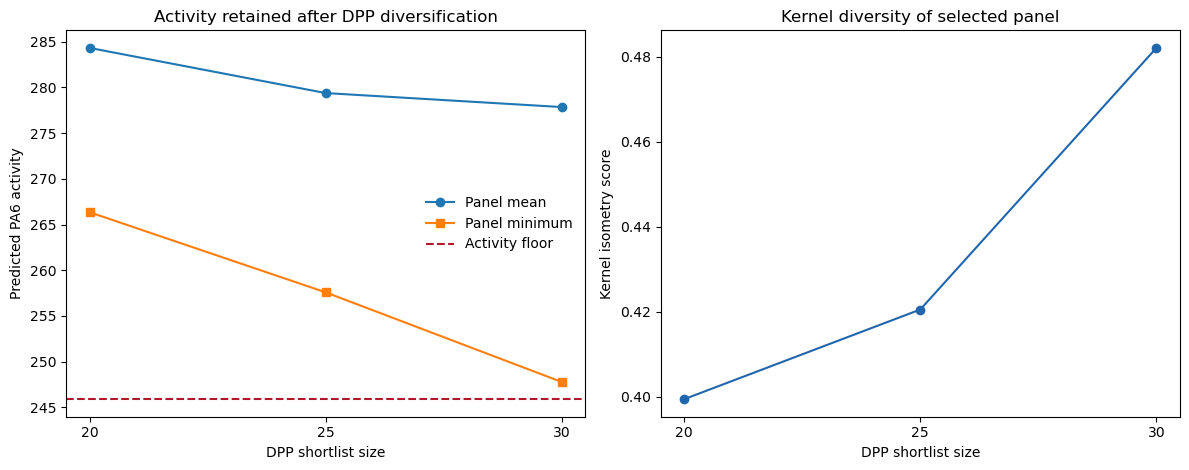

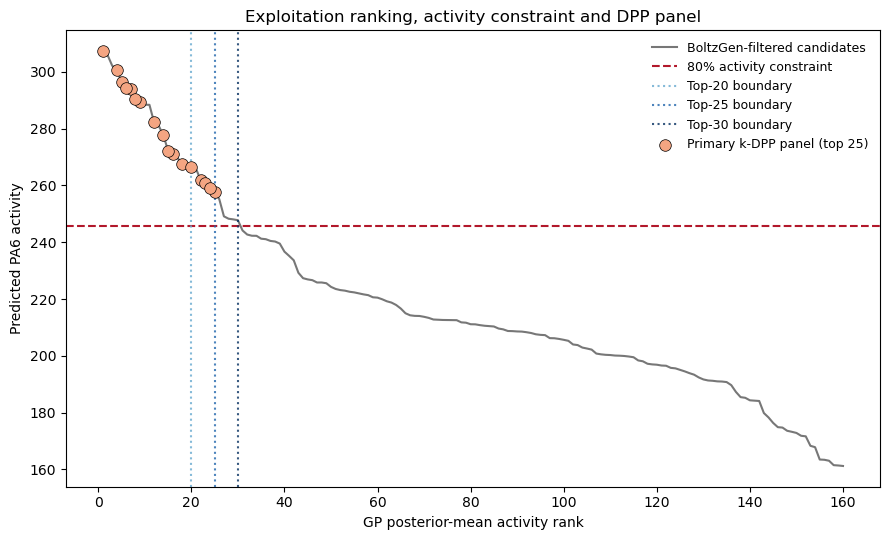

In [18]:
PLOT_DIR = OUT_DIR / "figures"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(
    shortlist_diagnostics["shortlist_size"],
    shortlist_diagnostics["mean_predicted_activity"],
    marker="o", label="Panel mean",
)
axes[0].plot(
    shortlist_diagnostics["shortlist_size"],
    shortlist_diagnostics["min_predicted_activity"],
    marker="s", label="Panel minimum",
)
axes[0].axhline(activity_floor, color="#b2182b", linestyle="--", label="Activity floor")
axes[0].set_xlabel("DPP shortlist size")
axes[0].set_ylabel("Predicted PA6 activity")
axes[0].set_title("Activity retained after DPP diversification")
axes[0].set_xticks(SHORTLIST_SIZES)
axes[0].legend(frameon=False)

axes[1].plot(
    shortlist_diagnostics["shortlist_size"],
    shortlist_diagnostics["isometry_score"],
    marker="o", color="#2166ac",
)
axes[1].set_xlabel("DPP shortlist size")
axes[1].set_ylabel("Kernel isometry score")
axes[1].set_title("Kernel diversity of selected panel")
axes[1].set_xticks(SHORTLIST_SIZES)
fig.tight_layout()
fig.savefig(PLOT_DIR / "shortlist_activity_diversity_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(
    candidates["activity_rank"], candidates["predicted_activity_gp_mean"],
    color="#777777", linewidth=1.5, label="BoltzGen-filtered candidates",
)
ax.axhline(activity_floor, color="#b2182b", linestyle="--", label="80% activity constraint")
for shortlist_size, colour in zip(SHORTLIST_SIZES, ["#67a9cf", "#2166ac", "#053061"]):
    boundary = float(eligible_candidates.iloc[shortlist_size - 1]["predicted_activity_gp_mean"])
    ax.axvline(shortlist_size, color=colour, linestyle=":", alpha=0.8,
               label=f"Top-{shortlist_size} boundary")
primary = selected_panels[PRIMARY_SHORTLIST_SIZE]
ax.scatter(
    primary["activity_rank"], primary["predicted_activity_gp_mean"],
    marker="o", s=70, color="#f4a582", edgecolor="black", linewidth=0.5,
    label=f"Primary k-DPP panel (top {PRIMARY_SHORTLIST_SIZE})",
    zorder=4,
)
ax.set_xlabel("GP posterior-mean activity rank")
ax.set_ylabel("Predicted PA6 activity")
ax.set_title("Exploitation ranking, activity constraint and DPP panel")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(PLOT_DIR / "activity_ranking_constraint_primary_panel.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation

This is a pure exploitation strategy with constrained diversification. It is not
uncertainty-driven active learning: posterior standard deviation is diagnostic
only. The activity constraint makes the diversity trade-off explicit and the
shortlist sensitivity analysis shows whether the primary panel depends strongly
on the arbitrary top-y choice.